# Resolución Trabajo Práctico 02

## Integrantes

- Gaspar Acevedo Zain

## Carga del dataset

### Imports y carga del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import entropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from category_encoders import TargetEncoder, HashingEncoder
from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_classif, mutual_info_classif, mutual_info_regression

In [2]:
df_procesado = pd.read_csv("../dataset/sneep-2023-procesamiento.csv")

In [3]:
# Configuramos el output display con 100 filas
pd.options.display.max_rows = 100
# Configuramos el output display con 100 columnas
pd.options.display.max_columns = 100

## Helper functions

In [4]:
# Devuelve datos relativos a columnas numéricas, tales como media, skewness, kurtosis, entre otros
def get_metrics_from_numeric_column(data, column):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    moda = (data[column]).mode()[0]
    mediana = (data[column]).median()
    var = (data[column]).var()
    std = (data[column]).std()
    min = (data[column]).min()
    max = (data[column]).max()

    return media, moda, mediana, min, max, var, std, skewness, kurtosis

In [5]:
# Devuelve métricas relacionadas al rango Intercuartil
def get_iqr_metrics(data, column):
    Q1 = data[column].quantile(0.25)
    Q2 = data[column].quantile(0.50)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1
    min_iqr = Q1 - 1.5*IQR
    max_iqr = Q3 + 1.5*IQR

    return Q1, Q2, Q3, IQR, min_iqr, max_iqr

In [6]:
# defino un color default
default_green_color = "#1F968BFF"

# Código provisto por la materia
# Función para graficar Histogramas, junto con skewness, kurtosis, media, varianza, y/o desvío estandar
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, snk=False, color=default_green_color, xlabel=None):
    media, moda, mediana, min, max, var, std, skewness, kurtosis = get_metrics_from_numeric_column(data, column)

    x_label = xlabel if xlabel is not None else f'{column}'

    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde, color=color)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
    plt.axvline(media, color='red', linestyle='--', label='Media')
    plt.axvline(moda, color='purple', linestyle='--', label='Moda')
    plt.axvline(mediana, color='green', linestyle='--', label='Mediana')
    if mvd:
        plt.figtext(0.15, 0.8, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Moda: {moda:.2f}', fontsize=10, color='purple')
        plt.figtext(0.15, 0.66, f'Mediana: {mediana:.2f}', fontsize=10, color='green')
        plt.figtext(0.15, 0.59, f'Var: {var:.2f}', fontsize=10, color='black')
        plt.figtext(0.15, 0.52, f'Std: {std:.2f}', fontsize=10, color='black')
    plt.title(f'Variable: {x_label}')
    plt.xlabel(f'{x_label}')
    plt.ylabel('Frecuencia')
    plt.show()
    
    return

In [7]:
def graficar_comparacion_transformaciones(df_original, df_normalizado, df_estandarizado, 
                                          columns, titulos = ["Original", "Normalizado (MinMax)", "Estandarizado (Z-Score)"],
                                          figsize = (10,10), colores = ["gray", "blue", "red"]):
    fig, axes = plt.subplots(nrows=len(columns), ncols=3, figsize=figsize)

    if axes.shape == (3,):
        axes = axes.reshape(1,3)

    for i, col in enumerate(columns):
        sns.histplot(df_original[col], kde=True, ax=axes[i, 0], color=colores[0])
        sns.histplot(df_normalizado[col], kde=True, ax=axes[i, 1], color=colores[1])
        sns.histplot(df_estandarizado[col], kde=True, ax=axes[i, 2], color=colores[2])

        axes[i, 0].set_ylabel(col)
        for j in range(3):
            axes[i, j].set_xlabel("")
            axes[i, j].set_title(titulos[j])
    plt.tight_layout()
    plt.show()

In [8]:
def graficar_comparacion_tratamiento_outliers(df_original, df_media, df_mediana, df_moda, df_log, df_sqrt,
                                          col, titulos = ["Original", "Transformación logaritmica", "Transformación por raíz cuadrada", "Imputación por media", "Imputación por mediana", "Imputación por moda"],
                                          figsize = (10,10), colores = ["gray", "blue", "red", "green", "purple", "black"]):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=figsize)

    sns.histplot(df_original[col], kde=True, ax=axes[0, 0], color=colores[0])
    sns.histplot(df_log[col], kde=True, ax=axes[0, 1], color=colores[1])
    sns.histplot(df_sqrt[col], kde=True, ax=axes[0, 2], color=colores[2])

    sns.histplot(df_media[col], kde=True, ax=axes[1, 0], color=colores[3])
    sns.histplot(df_mediana[col], kde=True, ax=axes[1, 1], color=colores[4])
    sns.histplot(df_moda[col], kde=True, ax=axes[1, 2], color=colores[5])

    axes[0, 0].set_ylabel(col)

    for i in range (2):
        for j in range(3):
            axes[i, j].set_xlabel("")
            axes[i, j].set_title(titulos[i*3+j])
    plt.tight_layout()
    plt.show()

In [9]:
# Source: https://seaborn.pydata.org/examples/many_pairwise_correlations.html
def graficar_corrplot(corr, title, figsize=(10,5), mask=None):
    
    if (mask is None):
        mask = np.triu(np.ones_like(corr, dtype=bool))

    f, ax = plt.subplots(figsize=figsize)

    cmap = sns.diverging_palette(230, 20, as_cmap=True)

    sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True) 
    
    plt.title(title)
    plt.show()
    
    return    

## Paso 1 - Split del dataset

Antes de realizar operaciones tales como tratamiento de nulos, tratamiento de outliers, creación de nuevas features, entre otras, debemos separar el dataset en *train* y *test*.

### Paso 1.1 - Repaso de columnas

Comencemos repasando las columnas del dataset:

In [10]:
df_procesado.columns.tolist()

['provincia_descripcion',
 'establecimiento_descripcion',
 'edad',
 'genero_descripcion',
 'nacionalidad_descripcion',
 'estado_civil_descripcion',
 'nivel_instruccion_descripcion',
 'ultima_situacion_laboral_descripcion',
 'capacitacion_laboral_al_ingresar_descripcion',
 'ultimo_lugar_residencia_descripcion',
 'ultima_provincia_residencia_descripcion',
 'jurisdiccion_descripcion',
 'situacion_legal_descripcion',
 'establecimiento_procedencia_descripcion',
 'delito1_descripcion',
 'delito2_descripcion',
 'delito3_descripcion',
 'delito4_descripcion',
 'delito5_descripcion',
 'horas_trabajo_remunerado_descripcion',
 'participacion_programa_laboral',
 'participacion_programa_educativo_descripcion',
 'participacion_actividades_deportivas',
 'recibio_atencion_medica_ult_anio',
 'recibio_atencion_medica_ult_anio_descripcion',
 'recibio_visitas_ultimo_anio',
 'participo_alteracion_orden_ult_anio_descripcion',
 'tipo_infraccion_disciplinaria_descripcion',
 'sancion_aplicada_descripcion',
 'ca

In [11]:
df_procesado.head(3)

,provincia_descripcion,establecimiento_descripcion,edad,genero_descripcion,nacionalidad_descripcion,estado_civil_descripcion,nivel_instruccion_descripcion,ultima_situacion_laboral_descripcion,capacitacion_laboral_al_ingresar_descripcion,ultimo_lugar_residencia_descripcion,ultima_provincia_residencia_descripcion,jurisdiccion_descripcion,situacion_legal_descripcion,establecimiento_procedencia_descripcion,delito1_descripcion,delito2_descripcion,delito3_descripcion,delito4_descripcion,delito5_descripcion,horas_trabajo_remunerado_descripcion,participacion_programa_laboral,participacion_programa_educativo_descripcion,participacion_actividades_deportivas,recibio_atencion_medica_ult_anio,recibio_atencion_medica_ult_anio_descripcion,recibio_visitas_ultimo_anio,participo_alteracion_orden_ult_anio_descripcion,tipo_infraccion_disciplinaria_descripcion,sancion_aplicada_descripcion,calificacion_conducta_descripcion,tentativa_fugas_evasiones_descripcion,tentativa_suicidio,fue_lesionado_descripcion,duracion_condena_anios,duracion_condena_meses,tipo_condena,es_reincidente_descripcion,tiene_periodo_progresividad_descripcion,reparticion_descripcion,tuvo_salidas_transitorias_descripcion,incorporado_reg_semi_libertad_descripcion,participa_programa_pre_libertad,participa_programa_prision_discontinua_descripcion,participa_programa_semi_detencion_descripcion,tuvo_reduccion_pena_descripcion,mujer_tiene_hijos_intramuro
0,Tucumán,UNIDAD Nº 3 - ENCAUSADOS CONCEPCIÓN,57,Varón,Argentina,Casado/a,Terciario incompleto,Desocupado/a,No tiene ni oficio ni profesión,Urbano,Tucumán,FEDERAL,Condenado/a,Deriv. de una instit. Policial,Privación ilegítima de la libertad,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,0.0,No participa de ningún programa educativo,0.0,2,No,0.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Sin calificación,No,0,No fue lesionado,8,0,0.0,Primario/a,No se aplica ninguna,Provincial,No le fueron otorgadas,No está incorporado/a al régimen de semilibertad,0.0,No está incorporado/a,No tiene semidetención,No tuvo reducción de pena,NaN
1,Tucumán,UNIDAD Nº 3 - ENCAUSADOS CONCEPCIÓN,34,Varón,Argentina,Soltero/a,Primario incompleto,Trabajador/ra de tiempo parcial,No tiene ni oficio ni profesión,Urbano,Tucumán,PROVINCIAL - Tucumán,Condenado/a,Deriv. de una instit. Policial,Homicidios dolosos,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,0.0,No participa de ningún programa educativo,0.0,1,Si - Recibió Asistencia Médica,1.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Ejemplar,No,0,No fue lesionado,0,0,1.0,Primario/a,No se aplica ninguna,Provincial,No le fueron otorgadas,No está incorporado/a al régimen de semilibertad,0.0,No está incorporado/a,No tiene semidetención,No tuvo reducción de pena,NaN
2,Buenos Aires,UNIDAD 30 - GENERAL ALVEAR,42,Varón,Argentina,Soltero/a,Primario completo,Desocupado/a,No tiene ni oficio ni profesión,Urbano,Buenos Aires,PROVINCIAL - Buenos Aires,Procesado/a,Deriv. de otro establecimiento,Violaciones/Abuso sexual,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,0.0,No participa de ningún programa educativo,1.0,0,NaN,1.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Ejemplar,No,0,No fue lesionado,0,0,NaN,NaN,NaN,Provincial,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Como se pueder observar, quedaron las siguientes columnas correspondientes a `IDs`:

- `participacion_programa_laboral` (su descripción equivalente está en la columna `participacion_programa_educativo_descripcion`)
- `recibio_atencion_medica_ult_anio` (su descripción equivalente está en la columna `recibio_atencion_medica_ult_anio_descripcion`)

Se decide trabajar con las variables categóricas, por lo cual eliminamos aquellas que corresponden a `IDs`.

In [12]:
columnas_a_eliminar = [
    "participacion_programa_laboral",
    "recibio_atencion_medica_ult_anio"
]

In [13]:
df_procesado = df_procesado.drop(columns=columnas_a_eliminar)

In [14]:
df_procesado.columns.size

44

De esta manera, el dataset queda con *44 columnas*:

In [15]:
df_procesado.head(3)

,provincia_descripcion,establecimiento_descripcion,edad,genero_descripcion,nacionalidad_descripcion,estado_civil_descripcion,nivel_instruccion_descripcion,ultima_situacion_laboral_descripcion,capacitacion_laboral_al_ingresar_descripcion,ultimo_lugar_residencia_descripcion,ultima_provincia_residencia_descripcion,jurisdiccion_descripcion,situacion_legal_descripcion,establecimiento_procedencia_descripcion,delito1_descripcion,delito2_descripcion,delito3_descripcion,delito4_descripcion,delito5_descripcion,horas_trabajo_remunerado_descripcion,participacion_programa_educativo_descripcion,participacion_actividades_deportivas,recibio_atencion_medica_ult_anio_descripcion,recibio_visitas_ultimo_anio,participo_alteracion_orden_ult_anio_descripcion,tipo_infraccion_disciplinaria_descripcion,sancion_aplicada_descripcion,calificacion_conducta_descripcion,tentativa_fugas_evasiones_descripcion,tentativa_suicidio,fue_lesionado_descripcion,duracion_condena_anios,duracion_condena_meses,tipo_condena,es_reincidente_descripcion,tiene_periodo_progresividad_descripcion,reparticion_descripcion,tuvo_salidas_transitorias_descripcion,incorporado_reg_semi_libertad_descripcion,participa_programa_pre_libertad,participa_programa_prision_discontinua_descripcion,participa_programa_semi_detencion_descripcion,tuvo_reduccion_pena_descripcion,mujer_tiene_hijos_intramuro
0,Tucumán,UNIDAD Nº 3 - ENCAUSADOS CONCEPCIÓN,57,Varón,Argentina,Casado/a,Terciario incompleto,Desocupado/a,No tiene ni oficio ni profesión,Urbano,Tucumán,FEDERAL,Condenado/a,Deriv. de una instit. Policial,Privación ilegítima de la libertad,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,No participa de ningún programa educativo,0.0,No,0.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Sin calificación,No,0,No fue lesionado,8,0,0.0,Primario/a,No se aplica ninguna,Provincial,No le fueron otorgadas,No está incorporado/a al régimen de semilibertad,0.0,No está incorporado/a,No tiene semidetención,No tuvo reducción de pena,NaN
1,Tucumán,UNIDAD Nº 3 - ENCAUSADOS CONCEPCIÓN,34,Varón,Argentina,Soltero/a,Primario incompleto,Trabajador/ra de tiempo parcial,No tiene ni oficio ni profesión,Urbano,Tucumán,PROVINCIAL - Tucumán,Condenado/a,Deriv. de una instit. Policial,Homicidios dolosos,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,No participa de ningún programa educativo,0.0,Si - Recibió Asistencia Médica,1.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Ejemplar,No,0,No fue lesionado,0,0,1.0,Primario/a,No se aplica ninguna,Provincial,No le fueron otorgadas,No está incorporado/a al régimen de semilibertad,0.0,No está incorporado/a,No tiene semidetención,No tuvo reducción de pena,NaN
2,Buenos Aires,UNIDAD 30 - GENERAL ALVEAR,42,Varón,Argentina,Soltero/a,Primario completo,Desocupado/a,No tiene ni oficio ni profesión,Urbano,Buenos Aires,PROVINCIAL - Buenos Aires,Procesado/a,Deriv. de otro establecimiento,Violaciones/Abuso sexual,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,No participa de ningún programa educativo,1.0,NaN,1.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Ejemplar,No,0,No fue lesionado,0,0,NaN,NaN,NaN,Provincial,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df_procesado["tipo_condena"].unique()

array([ 0.,  1., nan])

El siguiente paso será dividir las columnas en distintos grupos, para tratarlas en pasos posteriores según corresponda:

Columnas *numéricas*:

- `edad`
- `duracion_condena_anios`
- `duracion_condena_meses`

Columnas *booleanas*:

- `participacion_actividades_deportivas`
- `recibio_visitas_ultimo_anio`
- `tentativa_suicidio`
- `participa_programa_pre_libertad`

*Otras* columnas:

- `tipo_condena`: presenta como valores únicos a `0`, `1`, y `nan`. No se tiene suficiente información para definirla como *booleana* o *categórica*.

Columna objetivo o *target*:

- `tuvo_reduccion_pena_descripcion`

El resto de las columnas son categóricas.

In [17]:
col_numericas = [
    "edad",
    "duracion_condena_anios",
    "duracion_condena_meses"
]

col_booleanas = [
    "participacion_actividades_deportivas",
    "recibio_visitas_ultimo_anio",
    "tentativa_suicidio",
    "participa_programa_pre_libertad"
]

col_otras = [
    "tipo_condena"
]

target = "tuvo_reduccion_pena_descripcion"

col_objetivo = [target]

In [18]:
col_categoricas = list(set(df_procesado.columns) - set(col_booleanas + col_otras + col_numericas + col_objetivo))

### Paso 1.2 - Split en Train y test

Con el fin de hacer el split de manera equilibrada entre clases (ver [stratify](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)), llenamos temporalmente los *nulos* con el string literal `nan`.
Luego, se imputarán según corresponda.

In [19]:
df_procesado[target] = df_procesado[target].fillna("nan")

In [20]:
# definimos un random_state
random_state = 649739
test_size = 0.3
X_train, X_test, y_train, y_test = train_test_split(
    df_procesado.drop(columns=target),
    df_procesado[target],
    random_state=random_state,
    test_size=test_size,
    stratify=df_procesado[target])

## Paso 2 - Tratamiento de nulos

### Paso 2.1 - Repaso de nulos en el dataset

A continuación se repasan las variables que tienen datos faltantes y su tipo, según lo analizado en el `Trabajo Práctico nro. 1`.

| Columna | Cantidad de datos faltantes | Tipo de causa de datos faltantes | Comentarios |
| --- | --- | --- | --- |
| provincia_descripcion                               |       0 | - | - |
| establecimiento_descripcion                         |    3012 | MCAR | - |
| genero_descripcion                                  |       0 | - | - |
| nacionalidad_descripcion                            |     721 | MCAR | - |
| estado_civil_descripcion                            |    2891 | MCAR | - |
| nivel_instruccion_descripcion                       |    7737 | MCAR | - |
| ultima_situacion_laboral_descripcion                |     889 | MCAR | - |
| capacitacion_laboral_al_ingresar_descripcion        |    4205 | MCAR | - |
| ultimo_lugar_residencia_descripcion                 |      65 | MCAR | - |
| ultima_provincia_residencia_descripcion             |     591 | MCAR | - |
| jurisdiccion_descripcion                            |      12 | MCAR | - |
| situacion_legal_descripcion                         |       0 | - | - |
| establecimiento_procedencia_descripcion             |    1900 | MCAR | - |
| delito1_descripcion                                 |     590 | MCAR | - |
| delito2_descripcion                                 |   87909 | MAR | Valores nulos son correctos, ya que no necesariamente puede haber más de un delito (`delito1_descripcion`) |
| delito3_descripcion                                 |  105385 | MAR | Valores nulos son correctos, ya que no necesariamente puede haber más de un delito (`delito1_descripcion`) |
| delito4_descripcion                                 |  110104 | MAR | Valores nulos son correctos, ya que no necesariamente puede haber más de un delito (`delito1_descripcion`) |
| delito5_descripcion                                 |  111446 | MAR | Valores nulos son correctos, ya que no necesariamente puede haber más de un delito (`delito1_descripcion`) |
| horas_trabajo_remunerado_descripcion                |     423 | MCAR | - |
| participacion_programa_educativo_descripcion        |    4179 | MCAR | - |
| participacion_actividades_deportivas                |    2227 | MCAR | - |
| recibio_atencion_medica_ult_anio_descripcion        |    4819 | MCAR | - |
| recibio_visitas_ultimo_anio                         |    2812 | MCAR | - |
| participo_alteracion_orden_ult_anio_descripcion     |    1838 | MCAR | - |
| tipo_infraccion_disciplinaria_descripcion           |    1589 | MCAR | - |
| sancion_aplicada_descripcion                        |   95702 | MCAR | - |
| calificacion_conducta_descripcion                   |    3737 | MCAR | - |
| tentativa_fugas_evasiones_descripcion               |     227 | MCAR | - |
| tentativa_suicidio                                  |       0 | - | - |
| fue_lesionado_descripcion                           |     665 | MCAR | - |
| tipo_condena                                        |   46325 | MAR | 96.31% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| es_reincidente_descripcion                          |   48931 | MAR | 91.18% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| tiene_periodo_progresividad_descripcion             |   47173 | MAR | 94.58% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| reparticion_descripcion                             |    3012 | MCAR | - |
| tuvo_salidas_transitorias_descripcion               |   48567 | MAR | 91.86% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| incorporado_reg_semi_libertad_descripcion           |   46364 | MAR | 96.23% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| participa_programa_pre_libertad                     |   47713 | MAR | 93.5% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| participa_programa_prision_discontinua_descripcion  |   48167 | MAR | 92.63% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| participa_programa_semi_detencion_descripcion       |   47465 | MAR | 94% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| tuvo_reduccion_pena_descripcion                     |   48275 | MAR | 92.41% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| mujer_tiene_hijos_intramuro                         |  107325 | MAR | 100% de faltantes se deben a valores distintos de `Mujer` de la variable `genero_descripcion` |
| edad                                                |  1145   | MCAR  | Edad con valor igual a *cero*. |

### Paso 2.2 - Imputación de `MAR`

De la tabla del `Paso 2.1` se destacan los siguientes casos correspondientes a `MAR`:

1. Los valores distintos a `Condenado/a` en la variable `situacion_legal_descripcion` generan la mayoría de los valores *nulos* en las siguientes variables:
    1. `tipo_condena`, `es_reincidente_descripcion`, `tiene_periodo_progresividad_descripcion`, `tuvo_salidas_transitorias_descripcion`, `incorporado_reg_semi_libertad_descripcion`, `participa_programa_pre_libertad`, `participa_programa_prision_discontinua_descripcion`, `participa_programa_semi_detencion_descripcion` y `tuvo_reduccion_pena_descripcion`
    1. Esto es razonable, ya que estas variables describen situaciones correspondientes a personas que tienen condena.
1. Los valores *nulos* en la variable `mujer_tiene_hijos_intramuros` se deben a que el género (`genero_descripcion`) es distinto de `Mujer`, lo cual es lógico.
1. Las variables `delito2_descripcion`, `delito3_descripcion`, `delito4_descripcion` y `delito5_descripcion` tienen la mayoría de sus valores nulos. Esto se debe a que el registro NO necesariamente puede tener más de un delito.

Para resolverlos, se realizará lo siguiente:

1. Variables afectadas por `situacion_legal_descripcion`.
    1. Si `situacion_legal_descripcion` es ***distinto*** a `Condenado/a`, se imputará a cada una de las variables afectadas con el valor `Sin condena`.
    1. Si `situacion_legal_descripcion` es ***igual*** a `Condenado/a`, se imputará a cada una de las variables afectadas con la `moda` de este subjconjunto.
1. Registros con valores nulos en `mujer_tiene_hijos_intramuros`
    1. Si `genero_descripcion` es ***distinto*** a `Mujer`, se imputará con el valor `No aplica`
    1. Si `genero_descripcion` es ***igual*** a `Mujer`, se imputará con la `moda` de este subconjunto.
1. Las variables `delito2_descripcion`, `delito3_descripcion`, `delito4_descripcion` y `delito5_descripcion` serán eliminadas, ya que la mayoría son valores nulos.
    1. Los porcentajes de nulos son $78.51%$, $94.12%$, $98.34%$ y $99.53%$ respectivamente.

#### Paso 2.2.1 - Imputación de variables afectadas por valores distintos a `Condenado/a` en `situacion_legal_descripcion`

Primero, tenemos que convertir las variables `tipo_condena` y `participa_programa_pre_libertad` en string, ya que son (a priori) *booleanas*, pero sus valores son *float64*.

In [21]:
cols_to_string = [
    "tipo_condena",
    "participa_programa_pre_libertad"
]

for col in cols_to_string:
    train_not_na_mask = X_train[col].notna()
    test_not_na_mask = X_test[col].notna()

    X_train.loc[train_not_na_mask, col] = X_train.loc[train_not_na_mask, col].astype(str)
    X_test.loc[test_not_na_mask, col] = X_test.loc[test_not_na_mask, col].astype(str)

C:\Users\GasparAcevedo\AppData\Local\Temp\ipykernel_26828\864544693.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0.0' '0.0' '1.0' ... '0.0' '0.0' '0.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  X_train.loc[train_not_na_mask, col] = X_train.loc[train_not_na_mask, col].astype(str)
C:\Users\GasparAcevedo\AppData\Local\Temp\ipykernel_26828\864544693.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0.0' '0.0' '0.0' ... '0.0' '0.0' '0.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  X_test.loc[test_not_na_mask, col] = X_test.loc[test_not_na_mask, col].astype(str)
C:\Users\GasparAcevedo\AppData\Local\Temp\ipykernel_26828\864544693.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of 

In [22]:
const_condenado = "Condenado/a"
const_sin_condena = "Sin condena"
cols_afectadas_condenado = [
    "tipo_condena",
    "es_reincidente_descripcion",
    "tiene_periodo_progresividad_descripcion",
    "tuvo_salidas_transitorias_descripcion",
    "incorporado_reg_semi_libertad_descripcion",
    "participa_programa_pre_libertad",
    "participa_programa_prision_discontinua_descripcion",
    "participa_programa_semi_detencion_descripcion"
    #"tuvo_reduccion_pena_descripcion"
]

mask_condenados_train = X_train["situacion_legal_descripcion"] == const_condenado
mask_NO_condenados_train = X_train["situacion_legal_descripcion"] != const_condenado

mask_condenados_test = X_test["situacion_legal_descripcion"] == const_condenado
mask_NO_condenados_test = X_test["situacion_legal_descripcion"] != const_condenado

Imputamos los registros con `situacion_legal_descripcion` distinto a `Condenado/a` con el valor `Sin condena`

In [23]:
# Imputamos las columnas con valores DISTINTOS a Condenado/a, utilizando el valor `Sin condena`.

for col in cols_afectadas_condenado:
    X_train.loc[mask_NO_condenados_train, col] = const_sin_condena
    X_test.loc[mask_NO_condenados_test, col] = const_sin_condena

In [24]:
# Variable "tuvo_reduccion_pena_descripcion" es el target, por lo tanto actualizamos y_train e y_test.
y_train[mask_NO_condenados_train] = const_sin_condena
y_test[mask_NO_condenados_test] = const_sin_condena

Imputamos los registros con `situacion_legal_descripcion` igual a `Condenado/a` con la moda

In [25]:
for col in cols_afectadas_condenado:
    moda = X_train[mask_condenados_train][col].mode()[0]

    print(f"La columna {col} se imputará con la moda \"{moda}\"")
    X_train.loc[mask_condenados_train & (X_train[col]).isna(), col] = moda
    X_test.loc[mask_condenados_train & (X_test[col]).isna(), col] = moda

La columna tipo_condena se imputará con la moda "0.0"
La columna es_reincidente_descripcion se imputará con la moda "Primario/a"
La columna tiene_periodo_progresividad_descripcion se imputará con la moda "Período de tratamiento"
La columna tuvo_salidas_transitorias_descripcion se imputará con la moda "No le fueron otorgadas"
La columna incorporado_reg_semi_libertad_descripcion se imputará con la moda "No está incorporado/a al régimen de semilibertad"
La columna participa_programa_pre_libertad se imputará con la moda "0.0"
La columna participa_programa_prision_discontinua_descripcion se imputará con la moda "No está incorporado/a"
La columna participa_programa_semi_detencion_descripcion se imputará con la moda "No tiene semidetención"


Imputamos nulos en la variable target

Recordemos que al hacer el split seteamos los nulos con el string `nan`. Por eso, primero revertimos ese paso:

In [26]:
# reemplaza los valores distintos al string 'nan' con np.nan
y_train = y_train.where(y_train != 'nan', other=np.nan)
y_test = y_test.where(y_test != 'nan', other=np.nan)

In [27]:
moda_target = y_train[mask_condenados_train].mode()[0]

y_train[mask_condenados_train] = y_train[mask_condenados_train].fillna(moda_target)
y_test[mask_condenados_test] = y_test[mask_condenados_test].fillna(moda_target)

#### Paso 2.2.2 - Imputación con moda de variable `mujer_tiene_hijos_intramuro`

In [28]:
const_mujer = "Mujer"
const_no_aplica = "No aplica"

mask_mujer_train = X_train["genero_descripcion"] == const_mujer
mask_NO_mujer_train = X_train["genero_descripcion"] != const_mujer

mask_mujer_test = X_test["genero_descripcion"] == const_mujer
mask_NO_mujer_test = X_test["genero_descripcion"] != const_mujer

In [29]:
# Convertimos la variable "mujer_tiene_hijos_intramuro" en string
train_not_na_mask = X_train["mujer_tiene_hijos_intramuro"].notna()
test_not_na_mask = X_test["mujer_tiene_hijos_intramuro"].notna()

X_train.loc[train_not_na_mask, "mujer_tiene_hijos_intramuro"] = X_train.loc[train_not_na_mask, "mujer_tiene_hijos_intramuro"].astype(str)
X_test.loc[test_not_na_mask, "mujer_tiene_hijos_intramuro"] = X_test.loc[test_not_na_mask, "mujer_tiene_hijos_intramuro"].astype(str)

C:\Users\GasparAcevedo\AppData\Local\Temp\ipykernel_26828\3790756939.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0.0' '0.0' '0.0' ... '0.0' '0.0' '0.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  X_train.loc[train_not_na_mask, "mujer_tiene_hijos_intramuro"] = X_train.loc[train_not_na_mask, "mujer_tiene_hijos_intramuro"].astype(str)
C:\Users\GasparAcevedo\AppData\Local\Temp\ipykernel_26828\3790756939.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0.0' '0.0' '0.0' ... '0.0' '0.0' '0.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  X_test.loc[test_not_na_mask, "mujer_tiene_hijos_intramuro"] = X_test.loc[test_not_na_mask, "mujer_tiene_hijos_intramuro"].astype(str)


Imputamos los casos que no son `Mujer` con el valor `No aplica` para la columna `mujer_tiene_hijos_intramuro`

In [30]:
# Imputamos los nulos para los casos que NO corresponden a `Mujer`
X_train.loc[mask_NO_mujer_train, "mujer_tiene_hijos_intramuro"] = const_no_aplica
X_test.loc[mask_NO_mujer_test, "mujer_tiene_hijos_intramuro"] = const_no_aplica

En cuanto a los registros que si son `Mujer`, observamos que la columna `mujer_tiene_hijos_intramuro` no presenta nulos.

In [31]:
X_train[mask_mujer_train]["mujer_tiene_hijos_intramuro"].value_counts()

mujer_tiene_hijos_intramuro
0.0    3212
1.0      43
Name: count, dtype: int64

In [32]:
X_test[mask_mujer_test]["mujer_tiene_hijos_intramuro"].value_counts()

mujer_tiene_hijos_intramuro
0.0    1360
1.0      27
Name: count, dtype: int64

#### Paso 2.2.3 - Cálculo de porcentajes de nulos en variables `delito` y eliminación

In [33]:
# Se muestran la cantidad de nulos para las columnas de delitos
delitos = ["delito2_descripcion", "delito3_descripcion", "delito4_descripcion", "delito5_descripcion"]

total_registros = len(df_procesado)

for delito in delitos:
    cant_na = len(df_procesado[df_procesado[delito].isna()])
    print(f"Porcentaje de nulos en columna {delito}: {np.round(cant_na*100/total_registros, 2)}%")

Porcentaje de nulos en columna delito2_descripcion: 78.51%
Porcentaje de nulos en columna delito3_descripcion: 94.12%
Porcentaje de nulos en columna delito4_descripcion: 98.34%
Porcentaje de nulos en columna delito5_descripcion: 99.53%


In [34]:
X_train = X_train.drop(columns=delitos)
X_test = X_test.drop(columns=delitos)

In [35]:
for delito in delitos:
    col_categoricas.remove(delito)

### Paso 2.3 - Imputación de `MCAR`

Las siguientes variables son las que presentan nulos del tipo `MCAR`:

| Columna | Cantidad de datos faltantes | Comentarios |
| --- | --- | --- |
| establecimiento_descripcion                         |    3012 | - |
| nacionalidad_descripcion                            |     721 | - |
| estado_civil_descripcion                            |    2891 | - |
| nivel_instruccion_descripcion                       |    7737 | - |
| ultima_situacion_laboral_descripcion                |     889 | - |
| capacitacion_laboral_al_ingresar_descripcion        |    4205 | - |
| ultimo_lugar_residencia_descripcion                 |      65 | - |
| ultima_provincia_residencia_descripcion             |     591 | - |
| jurisdiccion_descripcion                            |      12 | - |
| establecimiento_procedencia_descripcion             |    1900 | - |
| delito1_descripcion                                 |     590 | - |
| horas_trabajo_remunerado_descripcion                |     423 | - |
| participacion_programa_educativo_descripcion        |    4179 | - |
| participacion_actividades_deportivas                |    2227 | - |
| recibio_atencion_medica_ult_anio_descripcion        |    4819 | - |
| recibio_visitas_ultimo_anio                         |    2812 | - |
| participo_alteracion_orden_ult_anio_descripcion     |    1838 | - |
| tipo_infraccion_disciplinaria_descripcion           |    1589 | - |
| sancion_aplicada_descripcion                        |   95702 | - |
| calificacion_conducta_descripcion                   |    3737 | - |
| tentativa_fugas_evasiones_descripcion               |     227 | - |
| fue_lesionado_descripcion                           |     665 | - |
| reparticion_descripcion                             |    3012 | - |
| edad                                                |  1145   | Edad con valor igual a *cero*. |

Como se observa en la tabla anterior, tenemos dos casos particulares:

1. La variable `sancion_aplicada_descripcion` presenta nulos en el $85.47$% de los registros.
1. La variable `edad` tiene $1145$ (aproximadamente el $1%$%) de valores con edad igual a cero.

Estos se resolverán de la siguiente manera:

1. La variable `sancion_aplicada_descripcion` será eliminada, ya que la mayoría de los registros tiene valores nulos.
1. Para la variable `edad` se imputarán los datos, en función de lo siguiente:
    1. Imputación por media: si los datos presentan distribución (aproximadamente) Normal (en el dataset de *train*).
    1. Imputación por mediana: si los datos NO presentan distribución (aproximadamente) Normal (en el dataset de *train*).

El resto de las variables serán imputadas por la *moda* (del dataset *train*), ya que son categóricas.

#### Paso 2.3.1 - Imputación de la variable `edad` con `mediana`

*X_train* tiene $787$ registros nulos (o registros con valor mínimo) y *X_test* tiene *358* registros nulos.

In [36]:
const_edad = "edad"

mask_min_edad_train = X_train[const_edad] == 0
mask_min_edad_test = X_test[const_edad] == 0

In [37]:
print(f"Cantidad de mínimo en X_train para edad: {len(X_train[mask_min_edad_train])}")
print(f"Cantidad de mínimo en X_test para edad: {len(X_test[mask_min_edad_test])}")

Cantidad de mínimo en X_train para edad: 787
Cantidad de mínimo en X_test para edad: 358


Se grafica la distribución de `edad` para determinar con qué métrica se imputará.

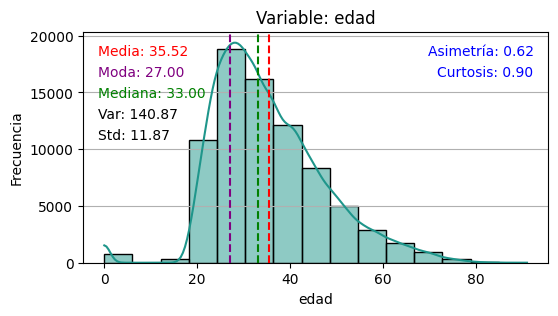

In [38]:
plot_histograma(data=X_train, column=const_edad, snk=True)

Como se observa en el gráfico anterior, la edad presenta `asimetría` (con un valor de $0.62$).

Debido a esto, se decide imputar l0s registros con edad igual a cero en la `edad` utilizando la `mediana`.

In [39]:
mediana_edad = (X_train[const_edad]).median()

In [40]:
X_train[const_edad] = (X_train[const_edad]).replace(0, mediana_edad)

In [41]:
X_test[const_edad] = (X_test[const_edad]).replace(0, mediana_edad)

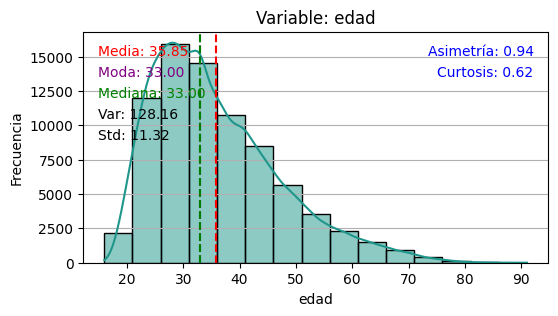

In [42]:
plot_histograma(data=X_train, column=const_edad, snk=True)

Como se observa en el gráfico anterior, al imputar por la *mediana* se altera la distribución de la variable `edad`.

#### Paso 2.3.2 - Imputación de variables categóricas mediante `moda`

Comenzamos imputando las variables categóricas utilizando la `moda`:

In [43]:
cols_a_imputar = [
    "establecimiento_descripcion",
    "nacionalidad_descripcion",
    "estado_civil_descripcion",
    "nivel_instruccion_descripcion",
    "ultima_situacion_laboral_descripcion",
    "capacitacion_laboral_al_ingresar_descripcion",
    "ultimo_lugar_residencia_descripcion",  
    "ultima_provincia_residencia_descripcion",
    "jurisdiccion_descripcion",
    "establecimiento_procedencia_descripcion",
    "delito1_descripcion",
    "horas_trabajo_remunerado_descripcion",
    "participacion_programa_educativo_descripcion",
    "participacion_actividades_deportivas",
    "recibio_atencion_medica_ult_anio_descripcion",
    "recibio_visitas_ultimo_anio",
    "participo_alteracion_orden_ult_anio_descripcion",
    "tipo_infraccion_disciplinaria_descripcion",
    "calificacion_conducta_descripcion",
    "tentativa_fugas_evasiones_descripcion",
    "fue_lesionado_descripcion",
    "reparticion_descripcion",
]

In [44]:
for col in cols_a_imputar:
    moda = (X_train[col]).mode()[0]

    X_train[col] = X_train[col].fillna(moda)
    X_test[col] = X_test[col].fillna(moda)

Finalmente, se borra la variable `sancion_aplicada_descripcion` de los dataset de *train* y *test*, ya que tiene una gran cantidad de nulos:

In [45]:
X_train.drop(columns=["sancion_aplicada_descripcion"], inplace=True)
X_test.drop(columns=["sancion_aplicada_descripcion"], inplace=True)

In [46]:
col_categoricas.remove("sancion_aplicada_descripcion")

### Paso 2.4 - Validación de nulos

Validamos que no queden nulos en el dataset de *train*:

In [47]:
X_train.isna().sum()

provincia_descripcion                                 0
establecimiento_descripcion                           0
edad                                                  0
genero_descripcion                                    0
nacionalidad_descripcion                              0
estado_civil_descripcion                              0
nivel_instruccion_descripcion                         0
ultima_situacion_laboral_descripcion                  0
capacitacion_laboral_al_ingresar_descripcion          0
ultimo_lugar_residencia_descripcion                   0
ultima_provincia_residencia_descripcion               0
jurisdiccion_descripcion                              0
situacion_legal_descripcion                           0
establecimiento_procedencia_descripcion               0
delito1_descripcion                                   0
horas_trabajo_remunerado_descripcion                  0
participacion_programa_educativo_descripcion          0
participacion_actividades_deportivas            

Validamos que no queden nulos en el dataset de *test*:

In [48]:
X_test.isna().sum()

provincia_descripcion                                    0
establecimiento_descripcion                              0
edad                                                     0
genero_descripcion                                       0
nacionalidad_descripcion                                 0
estado_civil_descripcion                                 0
nivel_instruccion_descripcion                            0
ultima_situacion_laboral_descripcion                     0
capacitacion_laboral_al_ingresar_descripcion             0
ultimo_lugar_residencia_descripcion                      0
ultima_provincia_residencia_descripcion                  0
jurisdiccion_descripcion                                 0
situacion_legal_descripcion                              0
establecimiento_procedencia_descripcion                  0
delito1_descripcion                                      0
horas_trabajo_remunerado_descripcion                     0
participacion_programa_educativo_descripcion            

Se observa que las siguientes variables contienen nulos en *test*:

- `tipo_condena`
- `es_reincidente_descripcion`
- `tiene_periodo_progresividad_descripcion`
- `tuvo_salidas_transitorias_descripcion`
- `incorporado_reg_semi_libertad_descripcion`
- `participa_programa_pre_libertad`
- `participa_programa_prision_discontinua_descripcion`
- `participa_programa_semi_detencion_descripcion`

In [49]:
cols_na_test = [
    "tipo_condena",
    "es_reincidente_descripcion",
    "tiene_periodo_progresividad_descripcion",
    "tuvo_salidas_transitorias_descripcion",
    "incorporado_reg_semi_libertad_descripcion",
    "participa_programa_pre_libertad",
    "participa_programa_prision_discontinua_descripcion",
    "participa_programa_semi_detencion_descripcion"
]

In [50]:
for col in cols_na_test:
    print(f"""
    ================Valores únicos en la columna {col}================
    {X_test[col].unique()}
    ==================================================================
    """)


    ================Valores únicos en la columna tipo_condena================
    ['Sin condena' '0.0' nan '1.0']
    

    ================Valores únicos en la columna es_reincidente_descripcion================
    ['Sin condena' 'Reiterante' 'Primario/a' 'Reincidente (art. 50 CP)' nan]
    

    ================Valores únicos en la columna tiene_periodo_progresividad_descripcion================
    ['Sin condena' 'Período de tratamiento' 'No se aplica ninguna'
 'Período de observación' 'Período de prueba'
 'Período de libertad condicional' 'Se aplica otra caracterización' nan]
    

    ================Valores únicos en la columna tuvo_salidas_transitorias_descripcion================
    ['Sin condena' 'No le fueron otorgadas' nan
 'Si - goza de salidas transitorias' 'Revocadas durante el último año'
 'Suspendidas durante el último año']
    

    ================Valores únicos en la columna incorporado_reg_semi_libertad_descripcion================
    ['Sin condena' 'No está incorp

Como son todas categóricas (y algunas numéricas) optamos por imputar por la moda en ***train***:

In [51]:
for col in cols_na_test:
    moda = (X_train[col]).mode()[0]

    # X_train[col] = X_train[col].fillna(moda)
    X_test[col] = X_test[col].fillna(moda)

Corroboramos que no queden nulos en test:

In [52]:
X_test.isna().sum()

provincia_descripcion                                 0
establecimiento_descripcion                           0
edad                                                  0
genero_descripcion                                    0
nacionalidad_descripcion                              0
estado_civil_descripcion                              0
nivel_instruccion_descripcion                         0
ultima_situacion_laboral_descripcion                  0
capacitacion_laboral_al_ingresar_descripcion          0
ultimo_lugar_residencia_descripcion                   0
ultima_provincia_residencia_descripcion               0
jurisdiccion_descripcion                              0
situacion_legal_descripcion                           0
establecimiento_procedencia_descripcion               0
delito1_descripcion                                   0
horas_trabajo_remunerado_descripcion                  0
participacion_programa_educativo_descripcion          0
participacion_actividades_deportivas            

## Paso 3 - Tratamiento de outliers

### Paso 3.1 - Análisis de outliers

Comenzamos haciendo un análisis de outliers sobre las variables numéricas:

#### Paso 3.1.1 - Análisis de `edad`

A continuación, se muestra un análisis de outliers para la variable `edad`, utilizando gráficos (histogramas + boxplot), como así también *IQR*.

Se encontraron un total de $1754$ outliers en *train* ($2.24$%) y $710$ outliers en *test* ($2.11$%).

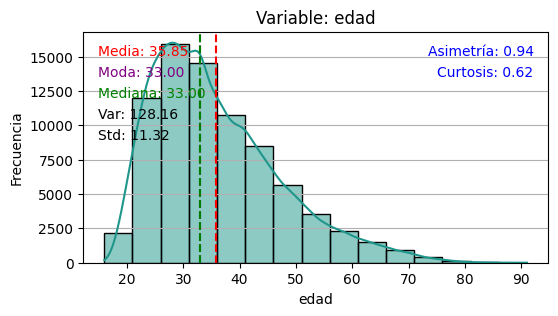

In [53]:
plot_histograma(X_train, const_edad, mvd= True, snk=True)

In [54]:
media, moda, mediana, min, max, var, std, skewness, kurtosis = get_metrics_from_numeric_column(X_train, const_edad)

print(f"""Variable Edad
      Media:      {media:.2f}
      Moda:       {moda:.2f}
      Mediana:    {mediana:.2f}
      Mínimo:     {min:.2f}
      Máximo:     {max:.2f}
      Varianza:   {var:.2f}
      Desvío:     {std:.2f}
      Skewness:   {skewness:.2f}
      Kurtosis:   {kurtosis:.2f}
""")

Variable Edad
      Media:      35.85
      Moda:       33.00
      Mediana:    33.00
      Mínimo:     16.00
      Máximo:     91.00
      Varianza:   128.16
      Desvío:     11.32
      Skewness:   0.94
      Kurtosis:   0.62



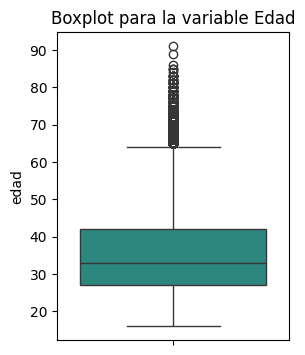

In [55]:
# Boxplot de la variable Edad
plt.figure(figsize=(3, 4))
sns.boxplot(data=X_train, y=const_edad, color=default_green_color)
plt.title("Boxplot para la variable Edad")
plt.show()

In [56]:
Q1, Q2, Q3, IQR, min_iqr, max_iqr = get_iqr_metrics(X_train, const_edad)

print(f"""Variable Edad
    Q1 (25%):   {Q1:.2f}
    Q2 (50%):   {Q2:.2f}
    Q3 (75%):   {Q3:.2f}
    IQR:        {IQR:.2f}
    Mín IQR:    {min_iqr:.2f}
    Max IQR:    {max_iqr:.2f}
""")

Variable Edad
    Q1 (25%):   27.00
    Q2 (50%):   33.00
    Q3 (75%):   42.00
    IQR:        15.00
    Mín IQR:    4.50
    Max IQR:    64.50



In [57]:
mask_edad_menor_min_iqr_train = X_train[const_edad] <= min_iqr
mask_edad_mayor_miax_iqr_train = X_train[const_edad] >= max_iqr

mask_edad_menor_min_iqr_test = X_test[const_edad] <= min_iqr
mask_edad_mayor_miax_iqr_test = X_test[const_edad] >= max_iqr

print(f"Cantidad de registros con edad menor al min_iqr ({min_iqr}) en \"Train\": {len(X_train[mask_edad_menor_min_iqr_train])}")
print(f"Cantidad de registros con edad menor al min_iqr ({min_iqr}) en \"Test\": {len(X_test[mask_edad_menor_min_iqr_test])}")

print(f"Cantidad de registros con edad mayor al max_iqr ({max_iqr}) en \"Train\": {len(X_train[mask_edad_mayor_miax_iqr_train])}")
print(f"Cantidad de registros con edad mayor al max_iqr ({max_iqr}) en \"Test\": {len(X_test[mask_edad_mayor_miax_iqr_test])}")

Cantidad de registros con edad menor al min_iqr (4.5) en "Train": 0
Cantidad de registros con edad menor al min_iqr (4.5) en "Test": 0
Cantidad de registros con edad mayor al max_iqr (64.5) en "Train": 1754
Cantidad de registros con edad mayor al max_iqr (64.5) en "Test": 710


#### Paso 3.1.2 - Análisis de `duracion_condena_anios`

A continuación, se muestra un análisis de outliers para la variable `duracion_condena_anios`, utilizando gráficos (histogramas + boxplot), como así también *IQR*.

Se encontraron un total de $2355$ outliers en *train* ($3$%) y $1039$ outliers en *test* ($3.01$%).

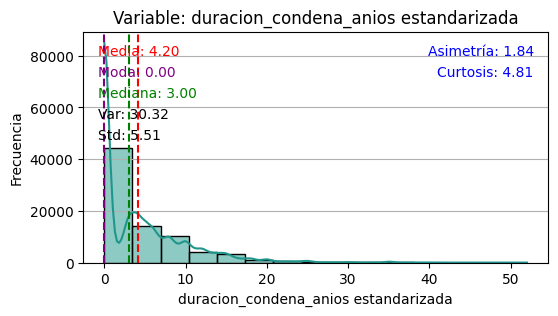

In [58]:
plot_histograma(X_train, "duracion_condena_anios", mvd= True, snk=True, xlabel="duracion_condena_anios estandarizada")

In [59]:
media, moda, mediana, min, max, var, std, skewness, kurtosis = get_metrics_from_numeric_column(X_train, "duracion_condena_anios")

print(f"""Variable duracion_condena_anios
      Media:      {media:.2f}
      Moda:       {moda:.2f}
      Mediana:    {mediana:.2f}
      Mínimo:     {min:.2f}
      Máximo:     {max:.2f}
      Varianza:   {var:.2f}
      Desvío:     {std:.2f}
      Skewness:   {skewness:.2f}
      Kurtosis:   {kurtosis:.2f}
""")

Variable duracion_condena_anios
      Media:      4.20
      Moda:       0.00
      Mediana:    3.00
      Mínimo:     0.00
      Máximo:     52.00
      Varianza:   30.32
      Desvío:     5.51
      Skewness:   1.84
      Kurtosis:   4.81



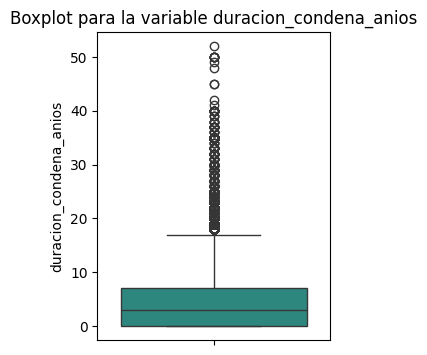

In [60]:
plt.figure(figsize=(3, 4))
sns.boxplot(data=X_train, y="duracion_condena_anios", color=default_green_color)
plt.title("Boxplot para la variable duracion_condena_anios")
plt.show()

In [61]:
Q1, Q2, Q3, IQR, min_iqr, max_iqr = get_iqr_metrics(X_train, "duracion_condena_anios")

print(f"""Variable duracion_condena_anios
    Q1 (25%):   {Q1:.2f}
    Q2 (50%):   {Q2:.2f}
    Q3 (75%):   {Q3:.2f}
    IQR:        {IQR:.2f}
    Mín IQR:    {min_iqr:.2f}
    Max IQR:    {max_iqr:.2f}
""")

Variable duracion_condena_anios
    Q1 (25%):   0.00
    Q2 (50%):   3.00
    Q3 (75%):   7.00
    IQR:        7.00
    Mín IQR:    -10.50
    Max IQR:    17.50



In [62]:
mask_menor_min_iqr_train = X_train["duracion_condena_anios"] <= min_iqr
mask_mayor_miax_iqr_train = X_train["duracion_condena_anios"] >= max_iqr

mask_menor_min_iqr_test = X_test["duracion_condena_anios"] <= min_iqr
mask_mayor_miax_iqr_test = X_test["duracion_condena_anios"] >= max_iqr

print(f"Cantidad de registros con duracion_condena_anios menor al min_iqr ({min_iqr}) en \"Train\": {len(X_train[mask_menor_min_iqr_train])}")
print(f"Cantidad de registros con duracion_condena_anios menor al min_iqr ({min_iqr}) en \"Test\": {len(X_test[mask_menor_min_iqr_test])}")

print(f"Cantidad de registros con duracion_condena_anios mayor al max_iqr ({max_iqr}) en \"Train\": {len(X_train[mask_mayor_miax_iqr_train])}")
print(f"Cantidad de registros con duracion_condena_anios mayor al max_iqr ({max_iqr}) en \"Test\": {len(X_test[mask_mayor_miax_iqr_test])}")

Cantidad de registros con duracion_condena_anios menor al min_iqr (-10.5) en "Train": 0
Cantidad de registros con duracion_condena_anios menor al min_iqr (-10.5) en "Test": 0
Cantidad de registros con duracion_condena_anios mayor al max_iqr (17.5) en "Train": 2355
Cantidad de registros con duracion_condena_anios mayor al max_iqr (17.5) en "Test": 1039


#### Paso 3.1.3 - Análisis de `duracion_condena_meses`

A continuación, se muestra un análisis de outliers para la variable `duracion_condena_meses`, utilizando gráficos (histogramas + boxplot), como así también *IQR*.

En este caso se encontró que la distribución tiene un valor muy alto de *Kurtosis* ($17.98$ en *train*), lo cual se debe a que presenta muchos outliers. Esto último puede observarse mejor en el *boxplot*.

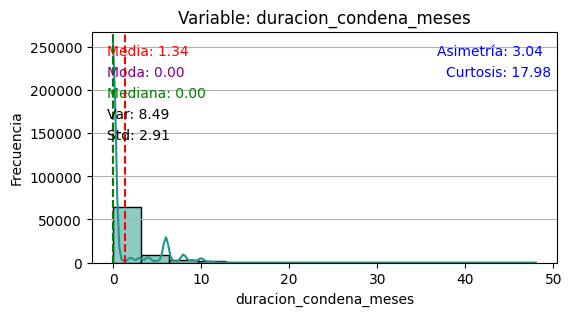

In [63]:
plot_histograma(X_train, "duracion_condena_meses", mvd= True, snk=True, xlabel="duracion_condena_meses")

In [64]:
media, moda, mediana, min, max, var, std, skewness, kurtosis = get_metrics_from_numeric_column(X_train, "duracion_condena_meses")

print(f"""Variable duracion_condena_meses
      Media:      {media:.2f}
      Moda:       {moda:.2f}
      Mediana:    {mediana:.2f}
      Mínimo:     {min:.2f}
      Máximo:     {max:.2f}
      Varianza:   {var:.2f}
      Desvío:     {std:.2f}
      Skewness:   {skewness:.2f}
      Kurtosis:   {kurtosis:.2f}
""")

Variable duracion_condena_meses
      Media:      1.34
      Moda:       0.00
      Mediana:    0.00
      Mínimo:     0.00
      Máximo:     48.00
      Varianza:   8.49
      Desvío:     2.91
      Skewness:   3.04
      Kurtosis:   17.98



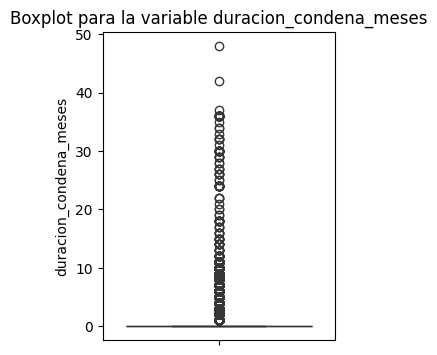

In [65]:
plt.figure(figsize=(3, 4))
sns.boxplot(data=X_train, y="duracion_condena_meses", color=default_green_color)
plt.title("Boxplot para la variable duracion_condena_meses")
plt.show()

In [66]:
Q1, Q2, Q3, IQR, min_iqr, max_iqr = get_iqr_metrics(X_train, "duracion_condena_meses")

print(f"""Variable duracion_condena_meses
    Q1 (25%):   {Q1:.2f}
    Q2 (50%):   {Q2:.2f}
    Q3 (75%):   {Q3:.2f}
    IQR:        {IQR:.2f}
    Mín IQR:    {min_iqr:.2f}
    Max IQR:    {max_iqr:.2f}
""")

Variable duracion_condena_meses
    Q1 (25%):   0.00
    Q2 (50%):   0.00
    Q3 (75%):   0.00
    IQR:        0.00
    Mín IQR:    0.00
    Max IQR:    0.00



In [67]:
mask_menor_min_iqr_train = X_train["duracion_condena_meses"] <= min_iqr
mask_mayor_miax_iqr_train = X_train["duracion_condena_meses"] >= max_iqr

mask_menor_min_iqr_test = X_test["duracion_condena_meses"] <= min_iqr
mask_mayor_miax_iqr_test = X_test["duracion_condena_meses"] >= max_iqr

print(f"Cantidad de registros con duracion_condena_meses menor al min_iqr ({min_iqr}) en \"Train\": {len(X_train[mask_menor_min_iqr_train])}")
print(f"Cantidad de registros con duracion_condena_meses menor al min_iqr ({min_iqr}) en \"Test\": {len(X_test[mask_menor_min_iqr_test])}")

print(f"Cantidad de registros con duracion_condena_meses mayor al max_iqr ({max_iqr}) en \"Train\": {len(X_train[mask_mayor_miax_iqr_train])}")
print(f"Cantidad de registros con duracion_condena_meses mayor al max_iqr ({max_iqr}) en \"Test\": {len(X_test[mask_mayor_miax_iqr_test])}")

Cantidad de registros con duracion_condena_meses menor al min_iqr (0.0) en "Train": 61101
Cantidad de registros con duracion_condena_meses menor al min_iqr (0.0) en "Test": 26273
Cantidad de registros con duracion_condena_meses mayor al max_iqr (0.0) en "Train": 78376
Cantidad de registros con duracion_condena_meses mayor al max_iqr (0.0) en "Test": 33591


#### Paso 3.1.4 - Definición estrategias para manejo de outliers

Este será el tratamiento de outliers que se hará en las siguientes variables:

- `edad`: se estudiará implementar una imputación por `media`, `mediana` y `moda` como así también transformaciones `logarítmicas` y por `raíz cuadrada`. Luego se analizarán sus distribuciones y se elegirá a la que mas se aproxime a una normal.
- `duracion_condena_anios`: se estudiará implementar una imputación por `media`, `mediana` y `moda` como así también transformaciones `logarítmicas` y por `raíz cuadrada`. Luego se analizarán sus distribuciones y se elegirá a la que mas se aproxime a una normal.
- `duracion_condena_meses`: debido a que tiene una gran cantidad de outliers, esta columna será eliminada.

### Paso 3.2 - tratamiento de outliers en variables numéricas

#### Paso 3.2.1 - tratamiento de outliers en variable `edad`

In [68]:
media, moda, mediana, min, max, var, std, skewness, kurtosis = get_metrics_from_numeric_column(X_train, const_edad)
Q1, Q2, Q3, IQR, min_iqr, max_iqr = get_iqr_metrics(X_train, const_edad)

In [69]:
print(f"Media: {media}\nMediana: {mediana}\nModa: {moda}")

Media: 35.84953302031234
Mediana: 33.0
Moda: 33


In [70]:
# Dataset con imputación por media
X_train_edad_media = pd.DataFrame(X_train[const_edad].copy(), columns=[const_edad])
mask_outliers_edad_iqr = (X_train_edad_media[const_edad] < min_iqr) | (X_train_edad_media[const_edad] > max_iqr)

X_train_edad_media.loc[mask_outliers_edad_iqr, const_edad] = media

C:\Users\GasparAcevedo\AppData\Local\Temp\ipykernel_26828\341752905.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '35.84953302031234' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train_edad_media.loc[mask_outliers_edad_iqr, const_edad] = media


In [71]:
# Dataset con imputación por mediana
X_train_edad_mediana = pd.DataFrame(X_train[const_edad].copy(), columns=[const_edad])
mask_outliers_edad_iqr = (X_train_edad_mediana[const_edad] < min_iqr) | (X_train_edad_mediana[const_edad] > max_iqr)

X_train_edad_mediana.loc[mask_outliers_edad_iqr, const_edad] = mediana

In [72]:
# Dataset con imputación por moda
X_train_edad_moda = pd.DataFrame(X_train[const_edad].copy(), columns=[const_edad])
mask_outliers_edad_iqr = (X_train_edad_moda[const_edad] < min_iqr) | (X_train_edad_moda[const_edad] > max_iqr)

X_train_edad_moda.loc[mask_outliers_edad_iqr, const_edad] = moda

In [73]:
# Dataset con transformación logarítmica
X_train_edad_logaritmica = pd.DataFrame(X_train[const_edad].copy(), columns=[const_edad])
X_train_edad_logaritmica[const_edad] = np.log1p(X_train_edad_logaritmica[const_edad])

In [74]:
# Dataset con transformación por raíz cuadrada
X_train_edad_sqrt = pd.DataFrame(X_train[const_edad].copy(), columns=[const_edad])
X_train_edad_sqrt[const_edad] = np.sqrt(X_train_edad_sqrt[const_edad])

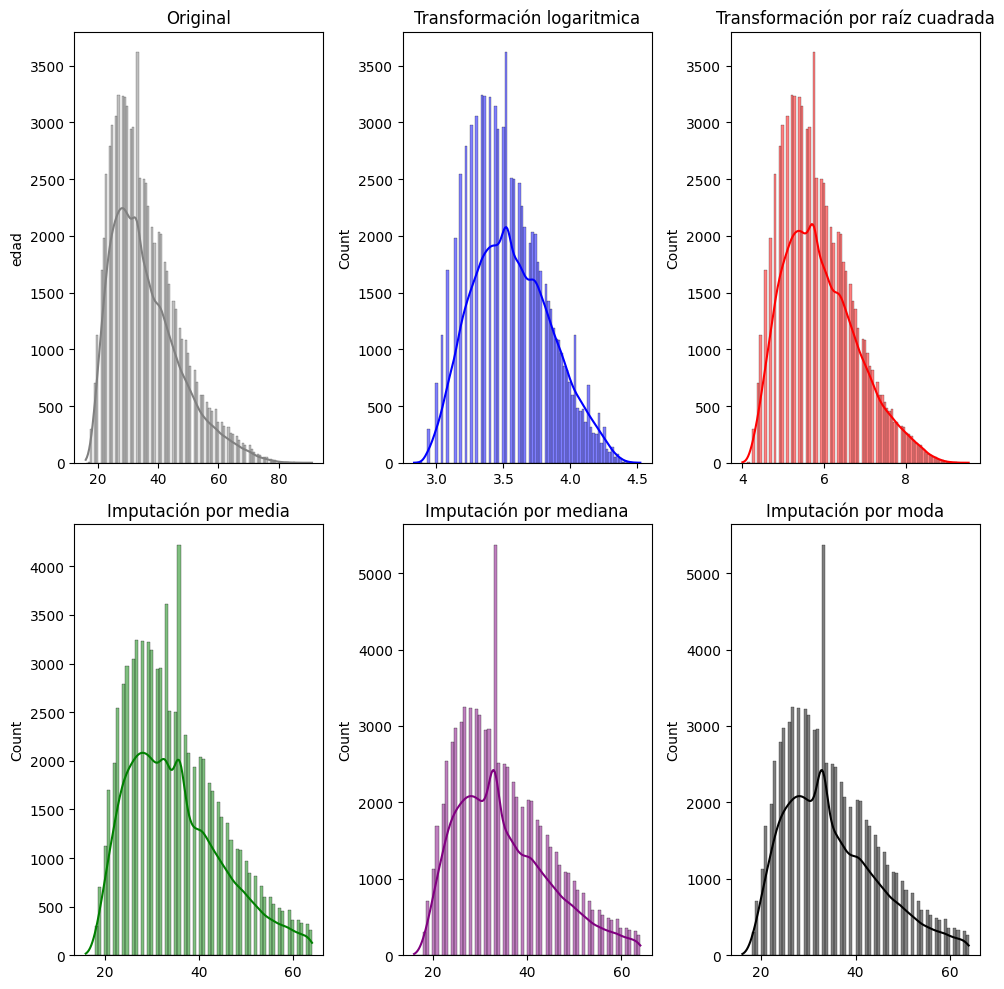

In [75]:
graficar_comparacion_tratamiento_outliers(X_train, X_train_edad_media, X_train_edad_mediana, X_train_edad_moda, X_train_edad_logaritmica, X_train_edad_sqrt, col=const_edad)

En los gráficos anteriores se puede observar que la `transformación logarítmica` es la que más se asemeja a una distribución normal, por lo cual la aplicaremos a la variable `edad` en *train* y *test*.

In [76]:
# Aplicamos transformación logarítmica a train y test por separado.
X_train[const_edad] = np.log1p(X_train[const_edad])
X_test[const_edad] = np.log1p(X_test[const_edad])

In [77]:
# se borran dataframes innecesarios
del X_train_edad_media, X_train_edad_mediana, X_train_edad_moda, X_train_edad_logaritmica, X_train_edad_sqrt

#### Paso 3.2.2 - tratamiento de outliers en variable `duracion_condena_anios`

In [78]:
media, moda, mediana, min, max, var, std, skewness, kurtosis = get_metrics_from_numeric_column(X_train, "duracion_condena_anios")
Q1, Q2, Q3, IQR, min_iqr, max_iqr = get_iqr_metrics(X_train, "duracion_condena_anios")

In [79]:
print(f"Media: {media}\nMediana: {mediana}\nModa: {moda}")

Media: 4.1961187098091255
Mediana: 3.0
Moda: 0


In [80]:
# Dataset con imputación por media
X_train_media = pd.DataFrame(X_train["duracion_condena_anios"].copy(), columns=["duracion_condena_anios"])
mask_outliers_iqr = (X_train_media["duracion_condena_anios"] < min_iqr) | (X_train_media["duracion_condena_anios"] > max_iqr)

X_train_media.loc[mask_outliers_iqr, "duracion_condena_anios"] = media

C:\Users\GasparAcevedo\AppData\Local\Temp\ipykernel_26828\4257049693.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '4.1961187098091255' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train_media.loc[mask_outliers_iqr, "duracion_condena_anios"] = media


In [81]:
# Dataset con imputación por mediana
X_train_mediana = pd.DataFrame(X_train["duracion_condena_anios"].copy(), columns=["duracion_condena_anios"])
mask_outliers_iqr = (X_train_mediana["duracion_condena_anios"] < min_iqr) | (X_train_mediana["duracion_condena_anios"] > max_iqr)

X_train_mediana.loc[mask_outliers_iqr, "duracion_condena_anios"] = mediana

In [82]:
# Dataset con imputación por moda
X_train_moda = pd.DataFrame(X_train["duracion_condena_anios"].copy(), columns=["duracion_condena_anios"])
mask_outliers_iqr = (X_train_moda["duracion_condena_anios"] < min_iqr) | (X_train_moda["duracion_condena_anios"] > max_iqr)

X_train_moda.loc[mask_outliers_iqr, "duracion_condena_anios"] = moda

In [83]:
# Dataset con transformación logarítmica
X_train_logaritmica = pd.DataFrame(X_train["duracion_condena_anios"].copy(), columns=["duracion_condena_anios"])
X_train_logaritmica["duracion_condena_anios"] = np.log1p(X_train_logaritmica["duracion_condena_anios"])

In [84]:
# Dataset con transformación por raíz cuadrada
X_train_sqrt = pd.DataFrame(X_train["duracion_condena_anios"].copy(), columns=["duracion_condena_anios"])
X_train_sqrt["duracion_condena_anios"] = np.sqrt(X_train_sqrt["duracion_condena_anios"])

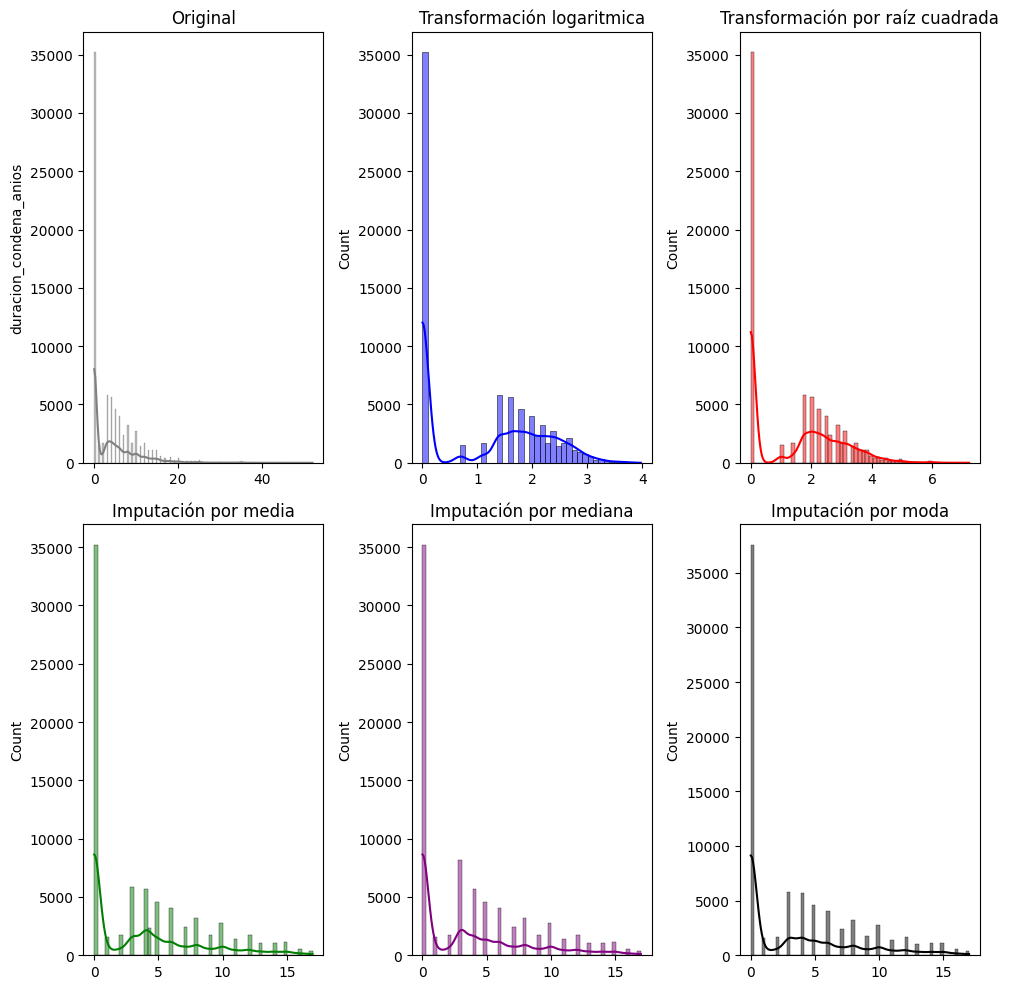

In [85]:
graficar_comparacion_tratamiento_outliers(X_train, X_train_media, X_train_mediana, X_train_moda, X_train_logaritmica, X_train_sqrt, col="duracion_condena_anios")

En los gráficos anteriores se puede observar que no hay una transformación que permita tener una distribución similar a la normal para la variable `duracion_condena_anios`.

Para determinar cual de estas transformaciones utilizaremos, nos basamos en la cantidad de outliers que tenga cada una luego de ser aplicada sobre *X_train*.

In [86]:
datasets = {
    "X_train": X_train,
    "Media": X_train_media,
    "Mediana": X_train_mediana,
    "Moda": X_train_moda,
    "Transformación logarítmica": X_train_logaritmica,
    "Transformación por raíz cuadrada": X_train_sqrt
}

total = len(X_train)

for key, value in datasets.items():
    ds = value
    Q1, Q2, Q3, IQR, min_iqr, max_iqr = get_iqr_metrics(ds, "duracion_condena_anios")

    mask_outliers_iqr = (ds["duracion_condena_anios"] < min_iqr) | (ds["duracion_condena_anios"] > max_iqr)
    cant_outliers = len(ds[mask_outliers_iqr])

    print(f"""=================================================================
          Dataset:                          {key}
          Cantidad de outliers en Train:    {cant_outliers}
          Porcentaje de outliers en Train:  {np.round(cant_outliers*100/total,2)}
          """)


          Dataset:                          X_train
          Cantidad de outliers en Train:    2355
          Porcentaje de outliers en Train:  3.0
          
          Dataset:                          Media
          Cantidad de outliers en Train:    950
          Porcentaje de outliers en Train:  1.21
          
          Dataset:                          Mediana
          Cantidad de outliers en Train:    950
          Porcentaje de outliers en Train:  1.21
          
          Dataset:                          Moda
          Cantidad de outliers en Train:    950
          Porcentaje de outliers en Train:  1.21
          
          Dataset:                          Transformación logarítmica
          Cantidad de outliers en Train:    0
          Porcentaje de outliers en Train:  0.0
          
          Dataset:                          Transformación por raíz cuadrada
          Cantidad de outliers en Train:    11
          Porcentaje de outliers en Train:  0.01
          


Como puede observarse en los resultados anteriores, la `transformación logarítmica` no tiene outliers en `X_train`, así que la aplicaremos tanto en *train* como *test*.

In [87]:
# Aplicamos transformación logarítmica a train y test por separado.
X_train["duracion_condena_anios"] = np.log1p(X_train["duracion_condena_anios"])
X_test["duracion_condena_anios"] = np.log1p(X_test["duracion_condena_anios"])

In [88]:
# se borran dataframes innecesarios
del X_train_media, X_train_mediana, X_train_moda, X_train_logaritmica, X_train_sqrt

#### Paso 3.2.3 - tratamiento de outliers en variable `duracion_condena_meses`

Como se mencionó en pasos anteriores, esta variable será eliminada tanto en *train* como *test* ya que tiene una gran cantidad de outliers.

In [89]:
X_train = X_train.drop(columns=["duracion_condena_meses"])
X_test = X_test.drop(columns=["duracion_condena_meses"])

In [90]:
col_numericas.remove("duracion_condena_meses")

### Paso 3.3 - conclusiones sobre el tratamiento de outliers

Estos son los resultados del análisis y tratamiento de outliers para las siguientes variables numéricas del dataset:

1. `edad`
    1. Se encontraron un total de $1754$ outliers en *train* ($2.24$%) y $710$ outliers en *test* ($2.11$%).
    1. Se exploraron las imputaciones por media, mediana y moda, como así también las transformaciones logarítmicas y por raíz cuadrada.
    1. Se aplicó una transformación logarítmica tanto en *train* como *test*, ya que esta transformación es la que genera una distribución más parecida a una *normal*.
1. `duracion_condena_anios`
    1. Se encontraron un total de $2355$ outliers en *train* ($3$%) y $1039$ outliers en *test* ($3.01$%).
    1. Se exploraron las imputaciones por media, mediana y moda, como así también las transformaciones logarítmicas y por raíz cuadrada.
    1. Como ninguna de estas transformaciones generó una distribución similar a una *normal*, se analizaron la cantidad de *nuevos outliers* al aplicarlas sobre *train*.
    1. Se aplicó una transformación logarítmica tanto en *train* como *test*, ya que luego de aplicarla sobre *train* no hubo más outliers.
1. `duracion_condena_meses`
    1. Se encontró que la distribución tiene un valor muy alto de *Kurtosis* ($17.98$ en *train*), lo cual se debe a que presenta muchos outliers.
    1. Se elimina la variable tanto en *train* como en *test*.

## Paso 4 - Creación de nuevas features

## Paso 5 - Discretización

## Paso 6 - Codificación

### Paso 6.1 - Codificación de variable target

Codificaremos la variable target `tuvo_reduccion_pena_descripcion` mediante label encoding.

Para ello, implementamos un [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) de la biblioteca *sklearn*.

1. Primero, hay que ajustar y transformar este *encoder* sobre los datos de *train*.
1. Una vez ajustado, podremos aplicar el mismo *encoder* sobre los datos de *test*.

In [91]:
# Creamos el encoder y hacemos fit_transform en train
labelEncoder = LabelEncoder()
y_train = labelEncoder.fit_transform(y_train)

In [92]:
# Una vez creado y ajustado el encoder, podemos aplicar la misma técnica en test
y_test = labelEncoder.transform(y_test)

### Paso 6.2 - Codificación de variable booleanas

Estas son las variables *booleanas* presentes en los datasets de *train* y *test*, con sus respectivos valores.

1. `participacion_actividades_deportivas`
    1. Los valores actuales son `1.` y `0.` (`Si` y `No`, respectivamente).
1. `recibio_visitas_ultimo_anio`
    1. Los valores actuales son `1.` y `0.` (`Si` y `No`, respectivamente).
1. `tentativa_suicidio`
    1. Esta variable cuenta con tres valores posibles: `0`, `1` y `2`.
    1. *NOTA*: técnicamente NO es booleana, ya que posee 3 valores posibles.
1. `participa_programa_pre_libertad`
    1. Esta variable posee los valores `1.`, `0.` (`Si` y `No`, respectivamente) y `Sin condena` (ver imputación de nulos en paso `2.2.1`).

Estos son los pasos que se realizarán para codificar la variable `participa_programa_pre_libertad`:

1. Transformaremos los valores `Si` y `No`, según tengan los valores `1` y `0`.
    1. Para el caso de `participa_programa_pre_libertad`, el valor `Sin condena` quedará tal cual se imputó.
    1. Para el caso de `tentativa_suicidio`, el valor `2` se transformará a `Otro`.
1. Se aplicará la técnica de `Frequency encoding`.

#### Paso 6.2.1 - Codificación mediante `Frequency encoding`

In [93]:
## lambda function que devuelve "Si" para los casos en que el valor es 1., sino devuelve "No"
si_no_encoder = lambda x: "Si" if x == "1.0" else ("No" if x == "0.0" else x)
si_no_encoder_numeric = lambda x: "Si" if x == 1.0 else ("No" if x == 0.0 else "Otro")

In [94]:
X_train["participa_programa_pre_libertad"] = X_train["participa_programa_pre_libertad"].apply(si_no_encoder)
X_test["participa_programa_pre_libertad"] = X_test["participa_programa_pre_libertad"].apply(si_no_encoder)

In [95]:
col_freq_encoding = ["participacion_actividades_deportivas", "recibio_visitas_ultimo_anio", "tentativa_suicidio"]

for col in col_freq_encoding:
    X_train[col] = X_train[col].apply(si_no_encoder_numeric)
    X_test[col] = X_test[col].apply(si_no_encoder_numeric)

In [96]:
col_freq_encoding.append("participa_programa_pre_libertad")

In [97]:
for col in col_freq_encoding:
    freq_encoding = X_train[col].value_counts(normalize=True)
    X_train[col] = X_train[col].map(freq_encoding)
    X_test[col] = X_test[col].map(freq_encoding)

### Paso 6.3 - Codificación de variable categóricas

En esta sección, se explorarán tres técnicas de encoding sobre las variable categóricas del dataset:

- `Ordinal encoding`: se analizará en los casos de variables que tengan un orden lógico.
- `Frequency encoding`: se analizará en los casos de variables en donde su frecuencia tenga una fuerte relación sobre la variable target (`tuvo_reduccion_pena_descripcion`).
- `Target encoding`: se analizará en los casos de variables que tengan alta cardinalidad.
- `Hashing encoding`: se analizará en casos de que haya alguna variable con cardinalidad extrema.

Las siguientes técnicas ***NO*** serán exploradas sobre las variable categóricas del dataset:

- `One-hot encoding`: ya que no se desea aumentar la dimensionalidad del dataset.
- `Cyclic encoding`: ya que no hay variables con patrones cíclicos en el dataset.

#### Paso 6.3.1 - Ordinal encoding

Estas son las columnas y sus respectivas categorías sobre las cuales se explorará el método de `ordinal encoding`:

1. `nivel_instruccion_descripcion`
    1. `Ninguno`
    1. `Primario incompleto`
    1. `Primario completo`
    1. `Secundario incompleto`
    1. `Secundario completo`
    1. `Terciario incompleto`
    1. `Universitario incompleto`
    1. `Terciario completo`
    1. `Universitario completo`
1. `tipo_infraccion_disciplinaria_descripcion`
    1. `No cometió Infracción disciplinaria`
    1. `Faltas leves`
    1. `Faltas media`
    1. `Faltas graves`

##### Paso 6.3.1.1 - Ordinal encoding en `nivel_instruccion_descripcion`

In [98]:
ordinal_encoder_nivel_instruccion = OrdinalEncoder(categories=[[
    "Ninguno",
    "Primario incompleto",
    "Primario completo",
    "Secundario incompleto",
    "Secundario completo",
    "Terciario incompleto",
    "Universitario incompleto",
    "Terciario completo",
    "Universitario completo"
]])

In [99]:
X_train["nivel_instruccion_descripcion"] = ordinal_encoder_nivel_instruccion.fit_transform(X_train[["nivel_instruccion_descripcion"]]).astype(int)

In [100]:
X_test["nivel_instruccion_descripcion"] = ordinal_encoder_nivel_instruccion.transform(X_test[["nivel_instruccion_descripcion"]]).astype(int)

In [101]:
# Se borra el encoder, para liberar memoria
del ordinal_encoder_nivel_instruccion

##### Paso 6.3.1.2 - Ordinal encoding en `tipo_infraccion_disciplinaria_descripcion`

In [102]:
ordinal_encoder_tipo_infraccion = OrdinalEncoder(categories=[[
    "No cometió Infracción disciplinaria",
    "Faltas leves",
    "Faltas media",
    "Faltas graves"
]])

In [103]:
X_train["tipo_infraccion_disciplinaria_descripcion"] = ordinal_encoder_tipo_infraccion.fit_transform(X_train[["tipo_infraccion_disciplinaria_descripcion"]]).astype(int)

In [104]:
X_test["tipo_infraccion_disciplinaria_descripcion"] = ordinal_encoder_tipo_infraccion.transform(X_test[["tipo_infraccion_disciplinaria_descripcion"]]).astype(int)

In [105]:
# Se borra el encoder, para liberar memoria
del ordinal_encoder_tipo_infraccion

#### Paso 6.3.2 - Frequency encoding

En este caso, se analizará la técnica de `frequency encoding` sobre la variable `situacion_legal_descripcion`, ya que la misma tiene una relación fuerte con la variable target (si es distinta a `Condenado/a`, el target tendrá el valor `Sin condena`).

In [106]:
freq_situacion_legal = X_train["situacion_legal_descripcion"].value_counts(normalize=True)
freq_situacion_legal

situacion_legal_descripcion
Condenado/a       0.601728
Procesado/a       0.387836
Otra situación    0.007834
Inimputable       0.002603
Name: proportion, dtype: float64

En la tabla anterior se observa que hay categorías poco frecuentes (`Otra situación` e `Inimputable`).

Para evitar que esto provoque overfitting, se opta por agruparlas junta a la categoría `Procesado/a` en la nuva categoría `Sin condena efectiva`.
- Más info: [Let's datasciende - frequency encoding](https://letsdatascience.com/frequency-encoding/), sección *IX. Cautions and Best Practices with Frequency Encoding*

In [107]:
situacion_legal_encoder = lambda x: "Sin condena efectiva" if x != "Condenado/a" else x

Al aplicar los cambios mencionados, obtenemos las siguientes frecuencias:

In [108]:
X_train["situacion_legal_descripcion"].apply(situacion_legal_encoder).value_counts(normalize=True)

situacion_legal_descripcion
Condenado/a             0.601728
Sin condena efectiva    0.398272
Name: proportion, dtype: float64

In [109]:
X_train["situacion_legal_descripcion"] = X_train["situacion_legal_descripcion"].apply(situacion_legal_encoder)
X_test["situacion_legal_descripcion"] = X_test["situacion_legal_descripcion"].apply(situacion_legal_encoder)

In [110]:
# Volvemos a generar el map de frecuencias
freq_situacion_legal = X_train["situacion_legal_descripcion"].value_counts(normalize=True)

In [111]:
X_train["situacion_legal_descripcion"] = X_train["situacion_legal_descripcion"].map(freq_situacion_legal)

In [112]:
X_test["situacion_legal_descripcion"] = X_test["situacion_legal_descripcion"].map(freq_situacion_legal)

#### Paso 6.3.3 - Target encoding

Comenzamos analizando la cardinalidad de las variables categóricas en *train*:

In [113]:
# Clase para analizar las cardinalidades
class CardinalityObject:
    pass

cardinalidades = []

for col in col_categoricas:
    obj = CardinalityObject()
    obj.nombre = col
    obj.cardinalidad = X_train[col].nunique()

    cardinalidades.append(obj)

cardinalidades.sort(key=lambda x: x.cardinalidad, reverse=True)

for x in cardinalidades:
    print(f"Columna: {x.nombre} - cardinalidad: {x.cardinalidad}")

Columna: establecimiento_descripcion - cardinalidad: 324
Columna: delito1_descripcion - cardinalidad: 30
Columna: jurisdiccion_descripcion - cardinalidad: 26
Columna: ultima_provincia_residencia_descripcion - cardinalidad: 24
Columna: provincia_descripcion - cardinalidad: 24
Columna: nacionalidad_descripcion - cardinalidad: 15
Columna: recibio_atencion_medica_ult_anio_descripcion - cardinalidad: 11
Columna: nivel_instruccion_descripcion - cardinalidad: 9
Columna: calificacion_conducta_descripcion - cardinalidad: 7
Columna: tiene_periodo_progresividad_descripcion - cardinalidad: 7
Columna: participacion_programa_educativo_descripcion - cardinalidad: 6
Columna: estado_civil_descripcion - cardinalidad: 6
Columna: incorporado_reg_semi_libertad_descripcion - cardinalidad: 5
Columna: participa_programa_prision_discontinua_descripcion - cardinalidad: 5
Columna: horas_trabajo_remunerado_descripcion - cardinalidad: 5
Columna: participa_programa_semi_detencion_descripcion - cardinalidad: 5
Colum

Si nos enfocamos en las columnas con cardinalidad mayor a $10$, tenemos:

| Columna | Cardinalidad |
| --- | --- |
| establecimiento_descripcion | 324 |
| delito1_descripcion | 30 |
| jurisdiccion_descripcion | 26 |
| ultima_provincia_residencia_descripcion | 24 |
| provincia_descripcion | 24 |
| nacionalidad_descripcion | 15 |
| recibio_atencion_medica_ult_anio_descripcion | 11 |

La columna `establecimiento_descripcion` tiene cardinalidad extrema ($324$), por lo cual será analizada en la siguiente sección (`Hashing encoding`).

Al resto de las columnas se les implementará `target encoding`.

##### Paso 6.3.3.1 - Implementación de Target encoding

In [114]:
columnas_para_target_encoding = [
    "delito1_descripcion", "jurisdiccion_descripcion", "ultima_provincia_residencia_descripcion",
    "provincia_descripcion", "nacionalidad_descripcion", "recibio_atencion_medica_ult_anio_descripcion"
]

In [115]:
for col in columnas_para_target_encoding:
    target_encoder = TargetEncoder()

    target_encoder_train = target_encoder.fit_transform(X_train[col], y_train)
    target_encoder_test = target_encoder.transform(X_test[col], y_test)

    X_train[col] = target_encoder_train
    X_test[col] = target_encoder_test

In [116]:
del target_encoder, target_encoder_train, target_encoder_test

#### Paso 6.3.4 - Hashing encoding

Se analizará la implementación de `Hashing encoding` para la columna `establecimiento_descripcion`, ya que tiene cardinalidad extrema ($324$).

Para ello, se utilizará la clase [HashingEncoder](https://contrib.scikit-learn.org/category_encoders/hashing.html) de *category encoders*.

Según la documentación, éste utiliza por defecto 8 bits para representar al feature (configurable mediante el parámetro `n_components`).

Comenzaremos utilizando el valor por defecto, y luego analizaremos otros en función de que tan útil sea este.

In [117]:
hashing_encoder_8_bits = HashingEncoder(n_components=8)

hash_encoded_8_bits = hashing_encoder_8_bits.fit_transform(X_train[["establecimiento_descripcion"]])
hash_encoded_8_bits = hash_encoded_8_bits.join(X_train["establecimiento_descripcion"])

In [118]:
cols_to_group_by = []
for i in range(8):
    cols_to_group_by.append(f"col_{i}")
hash_encoded_8_bits.groupby(cols_to_group_by)["establecimiento_descripcion"].nunique()

col_0  col_1  col_2  col_3  col_4  col_5  col_6  col_7
0      0      0      0      0      0      0      1        48
                                          1      0        39
                                   1      0      0        36
                            1      0      0      0        38
                     1      0      0      0      0        46
              1      0      0      0      0      0        46
       1      0      0      0      0      0      0        39
1      0      0      0      0      0      0      0        32
Name: establecimiento_descripcion, dtype: int64

La tabla anterior muestra la cantidad de valores únicos de `establecimiento_descripcion` para cada *hash* de ***8 bits*** (ver el valor de la última columna).

Se puede observar que hay colisiones. Por lo tanto, procedemos a analizar que sucede si se prueban ***10 bits***.

In [119]:
hashing_encoder_x_bits = HashingEncoder(n_components=10)

hash_encoded_x_bits = hashing_encoder_x_bits.fit_transform(X_train[["establecimiento_descripcion"]])
hash_encoded_x_bits = hash_encoded_x_bits.join(X_train["establecimiento_descripcion"])

In [120]:
cols_to_group_by = []
for i in range(10):
    cols_to_group_by.append(f"col_{i}")
hash_encoded_x_bits.groupby(cols_to_group_by)["establecimiento_descripcion"].nunique()

col_0  col_1  col_2  col_3  col_4  col_5  col_6  col_7  col_8  col_9
0      0      0      0      0      0      0      0      0      1        36
                                                        1      0        21
                                                 1      0      0        22
                                          1      0      0      0        27
                                   1      0      0      0      0        44
                            1      0      0      0      0      0        32
                     1      0      0      0      0      0      0        33
              1      0      0      0      0      0      0      0        35
       1      0      0      0      0      0      0      0      0        34
1      0      0      0      0      0      0      0      0      0        40
Name: establecimiento_descripcion, dtype: int64

De manera similar, se observa que al utilizar ***10 bits*** sigue habiendo colisiones.

Debido a que cada bit agregado representa una columna nueva, con el fin de aumentar demasiado la dimensionalidad del dataset se opta por aplicar *target encoding*.

In [121]:
target_encoder_establecimiento = TargetEncoder()
establecimiento_train_encode = target_encoder_establecimiento.fit_transform(X_train["establecimiento_descripcion"], y_train)

In [122]:
establecimiento_test_encode = target_encoder_establecimiento.transform(X_test["establecimiento_descripcion"], y_test)

In [123]:
X_train["establecimiento_descripcion"] = establecimiento_train_encode
X_test["establecimiento_descripcion"] = establecimiento_test_encode

In [124]:
del target_encoder_establecimiento, establecimiento_train_encode, establecimiento_test_encode

#### Paso 6.3.5 - Encoding de variables restantes

A continuación, se muestran las variables que no fueron codificadas por el momento:

In [125]:
cols_codificadas = col_numericas.copy()
cols_categoricas_codificadas = [
    "situacion_legal_descripcion",
    "participa_programa_pre_libertad",
    "participacion_actividades_deportivas",
    "recibio_visitas_ultimo_anio",
    "tentativa_suicidio",
    "delito1_descripcion",
    "jurisdiccion_descripcion",
    "ultima_provincia_residencia_descripcion",
    "provincia_descripcion",
    "nacionalidad_descripcion",
    "recibio_atencion_medica_ult_anio_descripcion",
    "establecimiento_descripcion",
    "nivel_instruccion_descripcion",
    "tipo_infraccion_disciplinaria_descripcion"
]
cols_codificadas.extend(cols_categoricas_codificadas)

cols_sin_codificar = list(set(X_train.columns) - set(cols_codificadas))

cardinalidades_sin_codificar = []

for col in cols_sin_codificar:
    obj = CardinalityObject()
    obj.nombre = col
    obj.cardinalidad = X_train[col].nunique()

    cardinalidades_sin_codificar.append(obj)

cardinalidades_sin_codificar.sort(key=lambda x: x.cardinalidad, reverse=True)

for x in cardinalidades_sin_codificar:
    print(f"Columna: {x.nombre} - cardinalidad: {x.cardinalidad}")

Columna: calificacion_conducta_descripcion - cardinalidad: 7
Columna: tiene_periodo_progresividad_descripcion - cardinalidad: 7
Columna: participacion_programa_educativo_descripcion - cardinalidad: 6
Columna: estado_civil_descripcion - cardinalidad: 6
Columna: incorporado_reg_semi_libertad_descripcion - cardinalidad: 5
Columna: participa_programa_prision_discontinua_descripcion - cardinalidad: 5
Columna: horas_trabajo_remunerado_descripcion - cardinalidad: 5
Columna: participa_programa_semi_detencion_descripcion - cardinalidad: 5
Columna: participo_alteracion_orden_ult_anio_descripcion - cardinalidad: 5
Columna: tuvo_salidas_transitorias_descripcion - cardinalidad: 5
Columna: genero_descripcion - cardinalidad: 5
Columna: es_reincidente_descripcion - cardinalidad: 4
Columna: fue_lesionado_descripcion - cardinalidad: 4
Columna: establecimiento_procedencia_descripcion - cardinalidad: 4
Columna: capacitacion_laboral_al_ingresar_descripcion - cardinalidad: 3
Columna: tentativa_fugas_evasion

Analizamos las frecuencias de valores de algunas variables de interés, para analizar si es conveniente aplicar `Frequency encoding`:

In [129]:
X_train["mujer_tiene_hijos_intramuro"].value_counts()

mujer_tiene_hijos_intramuro
No aplica    75121
0.0           3212
1.0             43
Name: count, dtype: int64

In [128]:
X_train["genero_descripcion"].value_counts()

genero_descripcion
Varón                   74975
Mujer                    3255
Trans Mujer/Travesti      118
Trans Varón                27
No Binario                  1
Name: count, dtype: int64

In [127]:
X_train["tuvo_salidas_transitorias_descripcion"].value_counts()

tuvo_salidas_transitorias_descripcion
No le fueron otorgadas               44160
Sin condena                          31215
Si - goza de salidas transitorias     2760
Revocadas durante el último año        130
Suspendidas durante el último año      111
Name: count, dtype: int64

In [126]:
X_train["calificacion_conducta_descripcion"].value_counts()

calificacion_conducta_descripcion
Ejemplar            46112
Buena               10990
Muy buena            9937
Sin calificación     6443
Regular              2519
Mala                 1207
Pésima               1168
Name: count, dtype: int64

Las tres variables analizadas, `genero_descripcion` (cardinalidad 5), `tuvo_salidas_transitorias_descripcion` (cardinalidad 5) y `calificacion_conducta_descripcion` (cardinalidad 7) se caracterizan por estar desbalanceadas.
- `genero_descripcion` tienen un desbalance muy fuerte, el cual no se resuelve incluso agrupando las clases minoritarias.
- `tuvo_salidas_transitorias_descripcion` es un caso similar, ya que la clase `Sin condena` no puede agruparse con las otras minoritarias (carece de sentido, ya que son subconjuntos disjuntos. Ver sección de *tratamiento de nulos*).
- `calificacion_conducta_descripcion` es similar al resto, ya que incluso agrupando las clases minoritarias seguiría habiendo desbalance.

De esta manera, descartamos aplicar `frequency encoding` sobre estas variables. El resto no será analizada, ya que subjetivamente no resultan interesantes.

A las columnas con cardinalidad igual a *2* se les aplicará `One Hot encoding`.

Estas columnas son `ultimo_lugar_residencia_descripcion` y `reparticion_descripcion`.

De esta manera, reemplazaremos las columnas originales por *dos* columnas nuevas, una por cada columna tratada, tanto en train y como en test.
- Como la cardinalidad es 2 para cada variable, *OneHotEncoder* genera 2 columnas por cada variable, pero al usar el parámetro `drop` de la clase [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html), se remueve una de estas columnas nuevas por cada variable.

In [130]:
cols_one_hot_encoding = ["ultimo_lugar_residencia_descripcion", "reparticion_descripcion"]

In [131]:
X_train = X_train.reset_index()
X_test = X_test.reset_index()

In [132]:
for col in cols_one_hot_encoding:
    ohe = OneHotEncoder(sparse_output=False, drop="first")
    
    encoded_array_train = ohe.fit_transform(X_train[[col]])
    columns_train = ohe.get_feature_names_out([col])
    encoded_train = pd.DataFrame(encoded_array_train, columns=columns_train)

    encoded_array_test = ohe.transform(X_test[[col]])
    columns_test = ohe.get_feature_names_out([col])
    encoded_test = pd.DataFrame(encoded_array_test, columns=columns_test)

    X_train = X_train.join(encoded_train)
    X_train = X_train.drop(columns=[col])

    X_test = X_test.join(encoded_test)
    X_test = X_test.drop(columns=[col])

In [135]:
del ohe, encoded_array_train, encoded_train, encoded_array_test, encoded_test

El resto de las columnas (cardinalidad mayor a 2 y menor a 10) serán codificadas mediante `Target encoding`, ya que `One hot encoding` aumentaría demasiado la cardinalidad, y no presentan un orden de cardinalidad para aplicar `Ordinal encoding`.

In [136]:
cols_sin_codificar = list(set(cols_sin_codificar) - set(cols_one_hot_encoding))

In [137]:
for col in cols_sin_codificar:
    target_encoder = TargetEncoder()

    target_encoder_train = target_encoder.fit_transform(X_train[col], y_train)
    target_encoder_test = target_encoder.transform(X_test[col], y_test)

    X_train[col] = target_encoder_train
    X_test[col] = target_encoder_test

In [138]:
del target_encoder, target_encoder_train, target_encoder_test

### Paso 6.4 - Conclusiones sobre las técnicas de codificación implementadas

Estas son las técnicas de codificación aplicadas en *train* y *test*:

- `Label encoding`: la cual se aplicó sobre la variable target `tuvo_reduccion_pena_descripcion`.
- `Frequency encoding`:
    - Se aplicó sobre todas las variables *booleanas*.
    - Se aplicó sobre la variable `situacion_legal_descripcion`, la cual tiene una fuerte relación con la variable *target* .
- `One-hot encoding`: se aplicó sobre las variables `ultimo_lugar_residencia_descripcion` y `reparticion_descripcion`.
- `Ordinal encoding`: se aplicó sobre la variable `nivel_instruccion_descripcion` y `tipo_infraccion_disciplinaria_descripcion`.    
- `Target encoding`
    - Originalmente, se aplicó sobre las variables `delito1_descripcion`, `jurisdiccion_descripcion`, `ultima_provincia_residencia_descripcion`, `provincia_descripcion`, `nacionalidad_descripcion`, `recibio_atencion_medica_ult_anio_descripcion`, `establecimiento_descripcion`.
    - Luego se aplicó al resto de las variables que no fueron codificadas.

Otros detalles importantes:

- También se estudió la implementación de `Hashing encoding` sobre la variable `establecimiento_descripcion`, pero este encoding fue descartado, ya que incluso creando *10* columnas nuevas, se generaban colisiones (además de que no se desea aumentar la dimensionalidad del dataset). Se optó por aplicar `Target encoding`.

## Paso 7 - Escalado

El siguiente paso corresponde a aplicar técnicas de normalización y estandarización a las siguientes variables a todas las variables codificadas:

In [139]:
cols_a_escalar = X_train.columns

### Paso 7.1 - Normalización

Aplicamos normalización a las variables mediante la clase [MixMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) de `Scikit-Learn`.

Para el dataset de `train` usamos la función [fit_transform](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#sklearn.preprocessing.MinMaxScaler.fit_transform), mientras que al dataset de `test` le aplicamos al función [transform](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#sklearn.preprocessing.MinMaxScaler.transform).

In [140]:
df_y_train = pd.DataFrame(y_train, columns=[target])
df_y_test = pd.DataFrame(y_test, columns=[target])

In [141]:
scaler = MinMaxScaler()
df_train_escalado = pd.DataFrame(scaler.fit_transform(X_train[cols_a_escalar]), columns=cols_a_escalar)
df_test_escalado = pd.DataFrame(scaler.transform(X_test[cols_a_escalar]), columns=cols_a_escalar)

target_scaler = MinMaxScaler()
y_train_escalado = pd.DataFrame(target_scaler.fit_transform(df_y_train), columns=[target])
y_test_escalado = pd.DataFrame(target_scaler.transform(df_y_test), columns=[target])

### Paso 7.2 - Estandarización

Estandarizamos a las variables mediante la clase [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) de `Scikit-Learn`.

Para el dataset de `train` usamos la función [fit_transform](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.fit_transform), mientras que al dataset de `test` le aplicamos al función [transform](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.transform).

In [142]:
standard_scaler = StandardScaler()
df_train_estandarizado = pd.DataFrame(standard_scaler.fit_transform(X_train[cols_a_escalar]), columns=cols_a_escalar)
df_test_estandarizado = pd.DataFrame(standard_scaler.transform(X_test[cols_a_escalar]), columns=cols_a_escalar)

target_standard_scaler = StandardScaler()
y_train_estandarizado = pd.DataFrame(target_standard_scaler.fit_transform(df_y_train), columns=[target])
y_test_estandarizado = pd.DataFrame(target_standard_scaler.transform(df_y_test), columns=[target])

### Paso 7.3 - Comparación mediante gráficos

#### Paso 7.3.1 - Gráfico de variables numéricas

A continuación se grafica la distribución de las variables numéricas en los dataset de `train` *original*, *normalizado* y *estandarizado*.

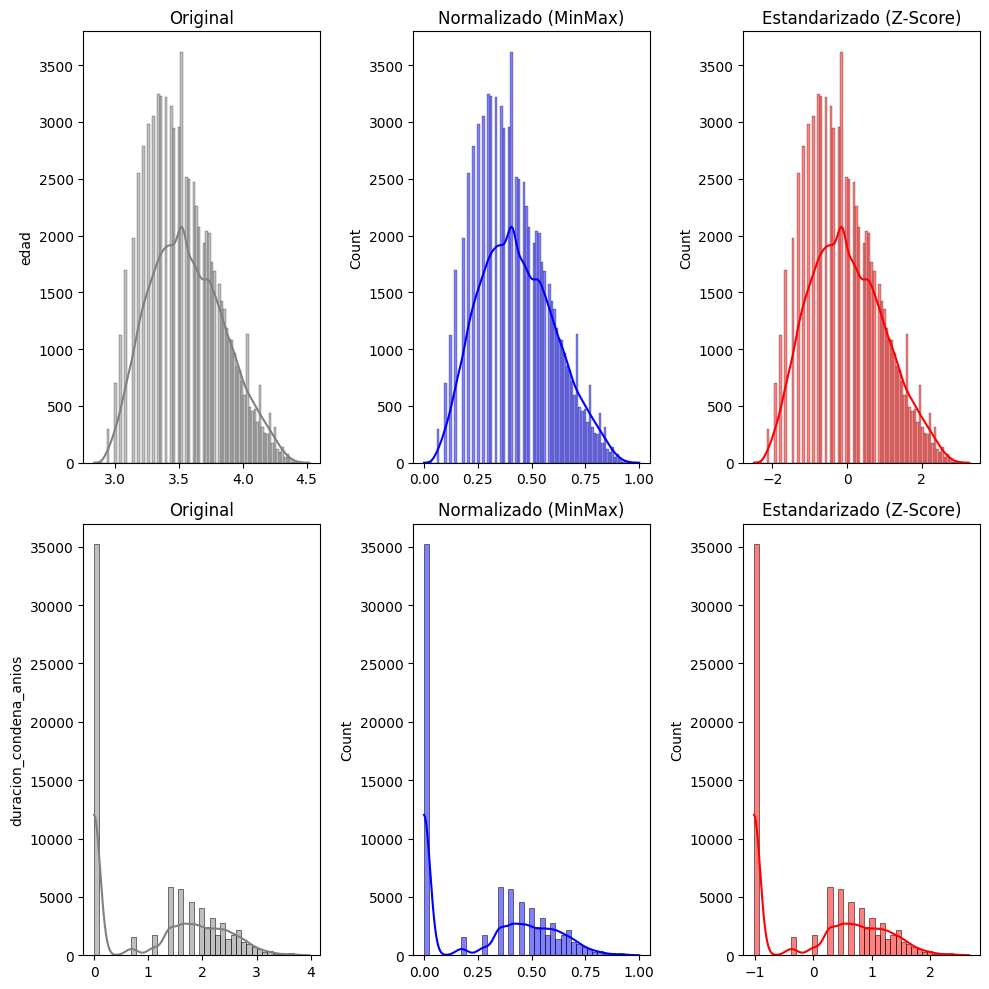

In [143]:
graficar_comparacion_transformaciones(df_original=X_train,
                                      df_normalizado=df_train_escalado,
                                      df_estandarizado=df_train_estandarizado,
                                      columns=col_numericas)

A continuación se grafica la distribución de las variables numéricas en los dataset de `test` *original*, *normalizado* y *estandarizado*.

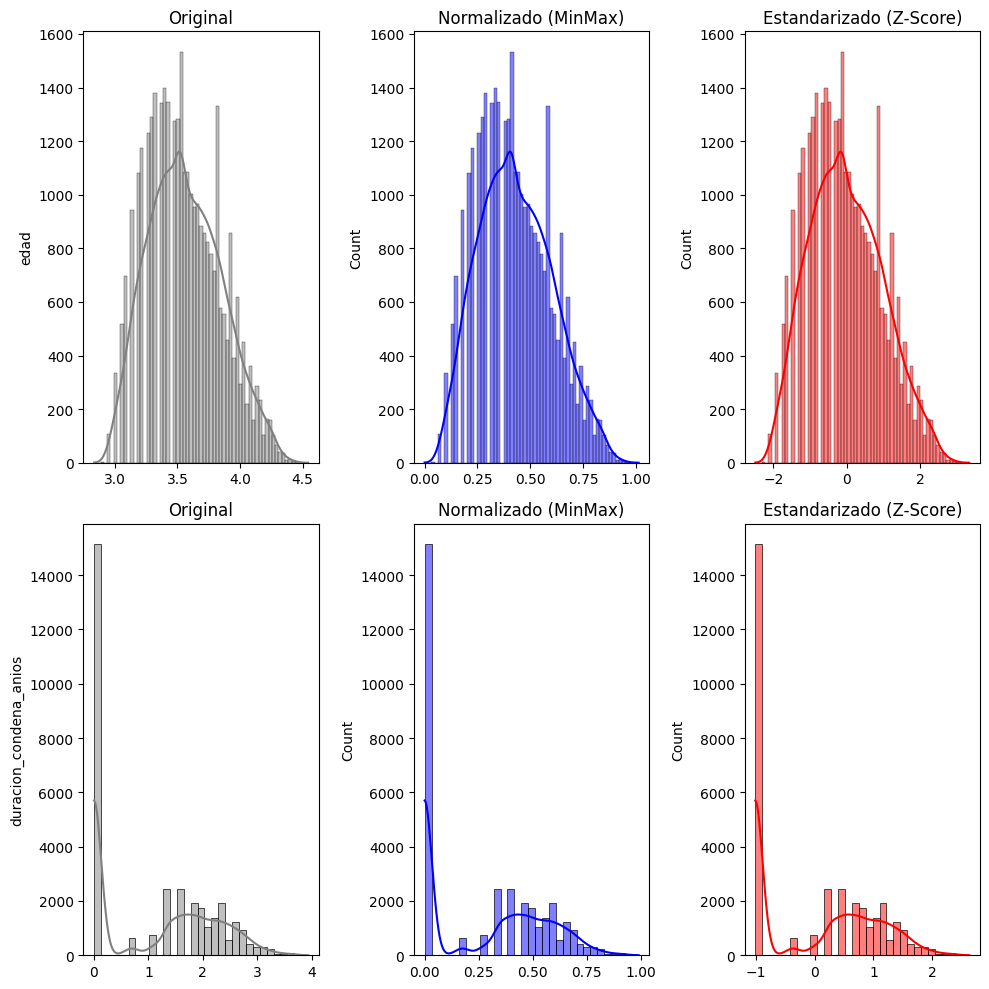

In [144]:
graficar_comparacion_transformaciones(df_original=X_test,
                                      df_normalizado=df_test_escalado,
                                      df_estandarizado=df_test_estandarizado,
                                      columns=col_numericas)

Como se puede observar en los gráficos, las distribuciones se mantienen para todas las variables, tanto al estandarizar como al normalizar los datasets de *train* y *test*.

Se opta por utilizar la estandarización de estas variables, ya que esta puede resultar útil al trabajar con algoritmos tales como `Regresión Lineal` y `SVM`, mientras que la normalización resulta útil para algoritmos tales como `KNN`, el cual es poco probable que se utilice en casos como este.

Por este motivo, reemplazaremos las columnas numéricas el los datasets *train* y *test* por sus valores `estandarizados`.

#### Paso 7.3.2 - Gráfico de variables no numéricas codificadas

A continuación se grafica la distribución de ***algunas*** de las variables categóricas codificadas en los dataset de `train` *original*, *normalizado* y *estandarizado*.

Estas corresponden a las columnas que fueron codificadas previas al `Paso 6.3.5`.

In [145]:
cols_categoricas_codificadas = [
    "situacion_legal_descripcion",
    "participa_programa_pre_libertad",
    "participacion_actividades_deportivas",
    "recibio_visitas_ultimo_anio",
    "tentativa_suicidio",
    "delito1_descripcion",
    "jurisdiccion_descripcion",
    "ultima_provincia_residencia_descripcion",
    "provincia_descripcion",
    "nacionalidad_descripcion",
    "recibio_atencion_medica_ult_anio_descripcion",
    "establecimiento_descripcion",
    "nivel_instruccion_descripcion",
    "tipo_infraccion_disciplinaria_descripcion"
]

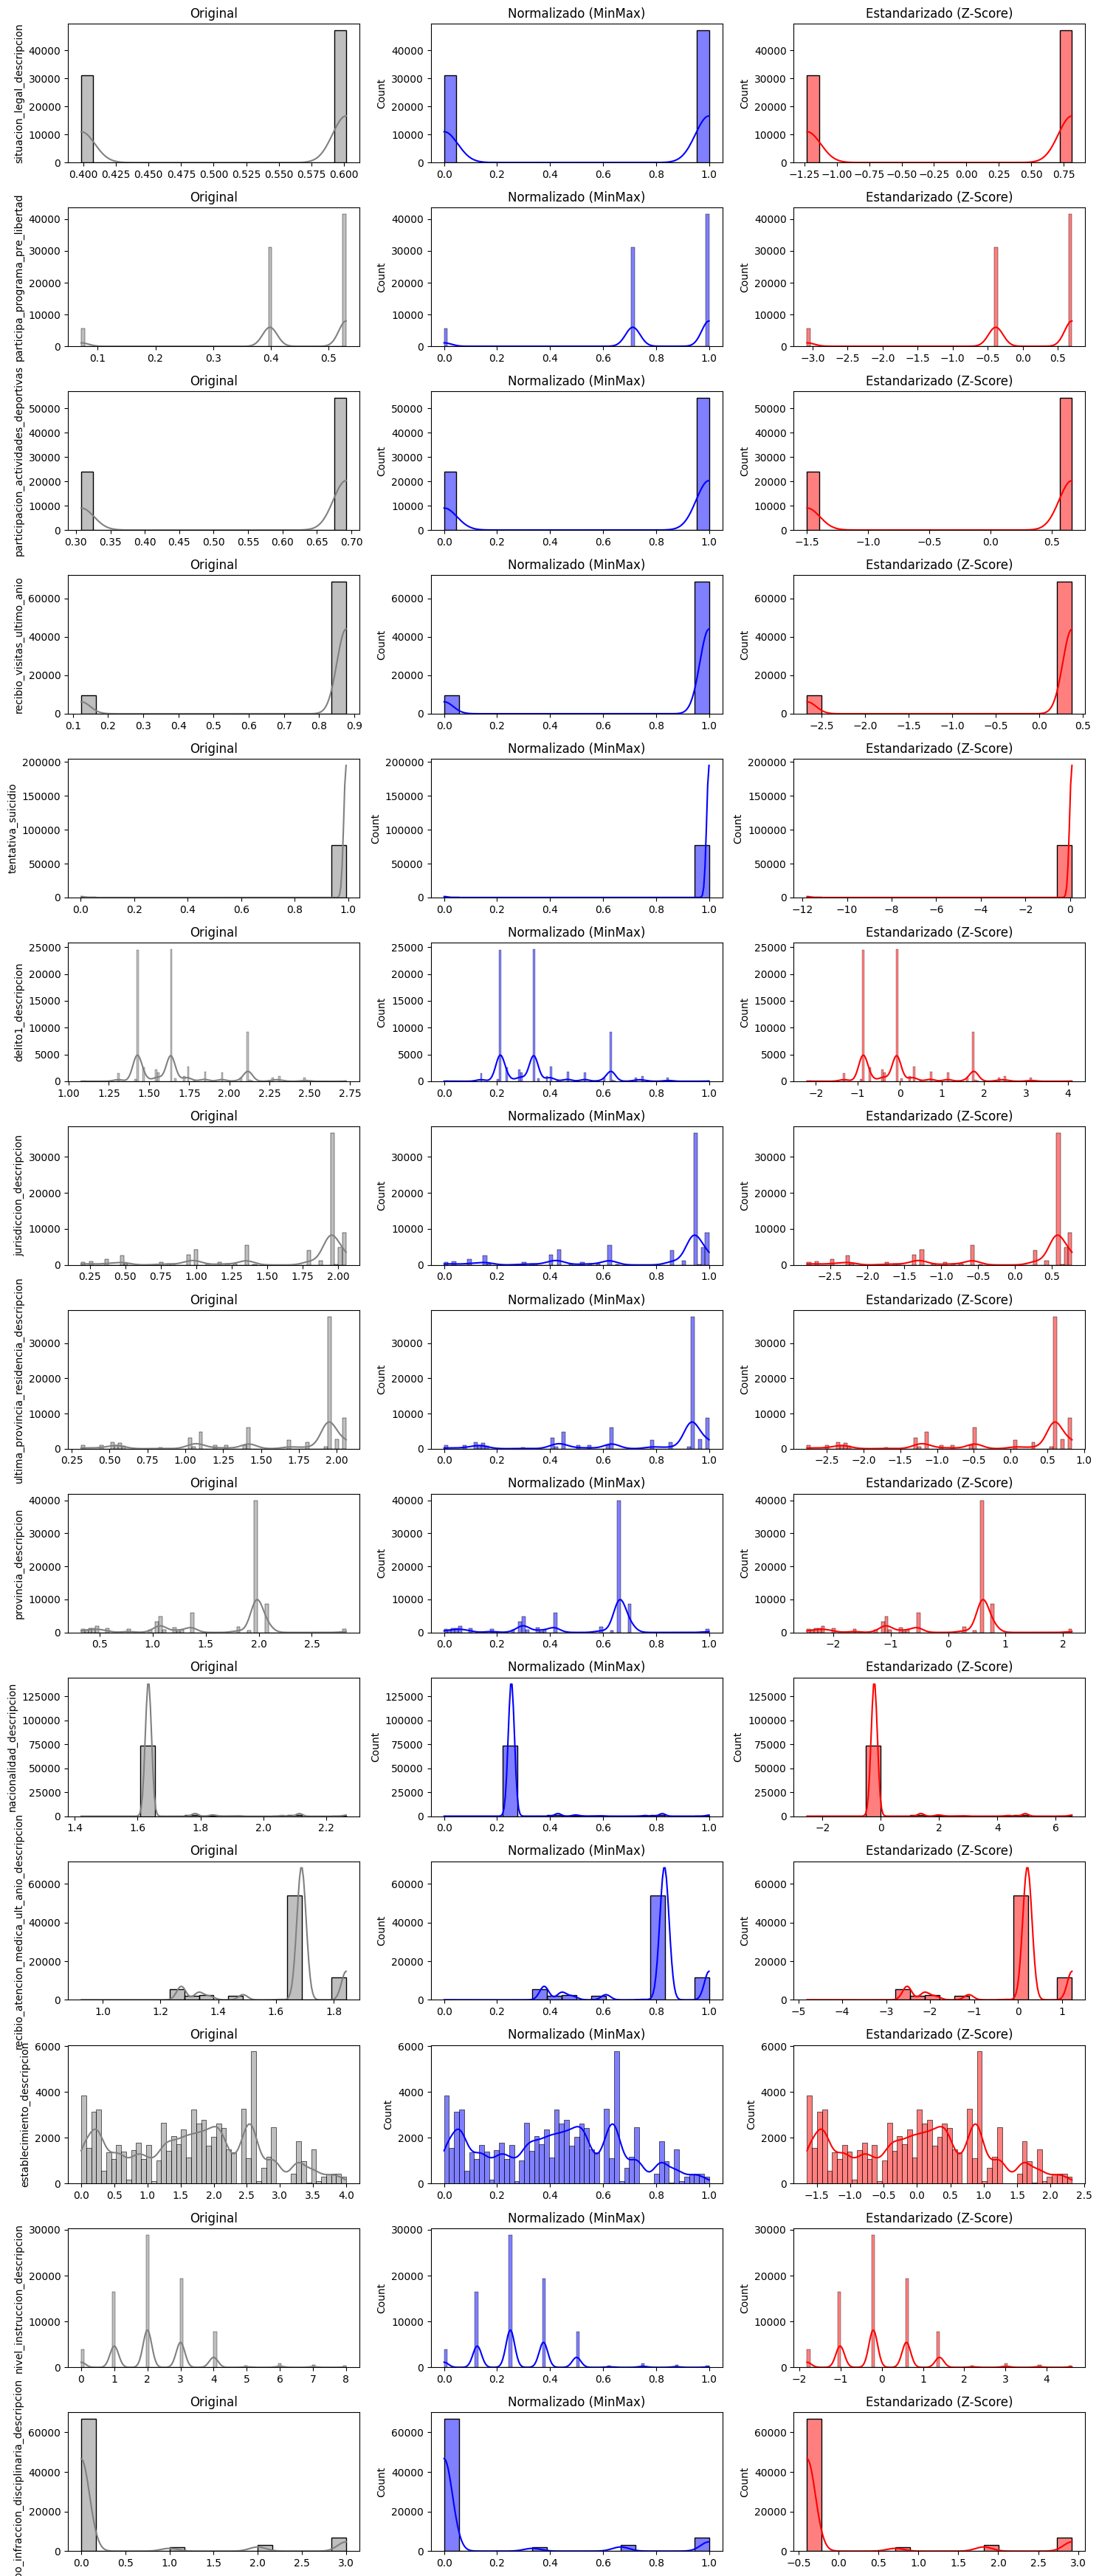

In [146]:
graficar_comparacion_transformaciones(df_original=X_train,
                                      df_normalizado=df_train_escalado,
                                      df_estandarizado=df_train_estandarizado,
                                      columns=cols_categoricas_codificadas,
                                      figsize = (15,35))

A continuación se grafica la distribución de las variables categóricas codificadas en los dataset de `train` *original*, *normalizado* y *estandarizado*.

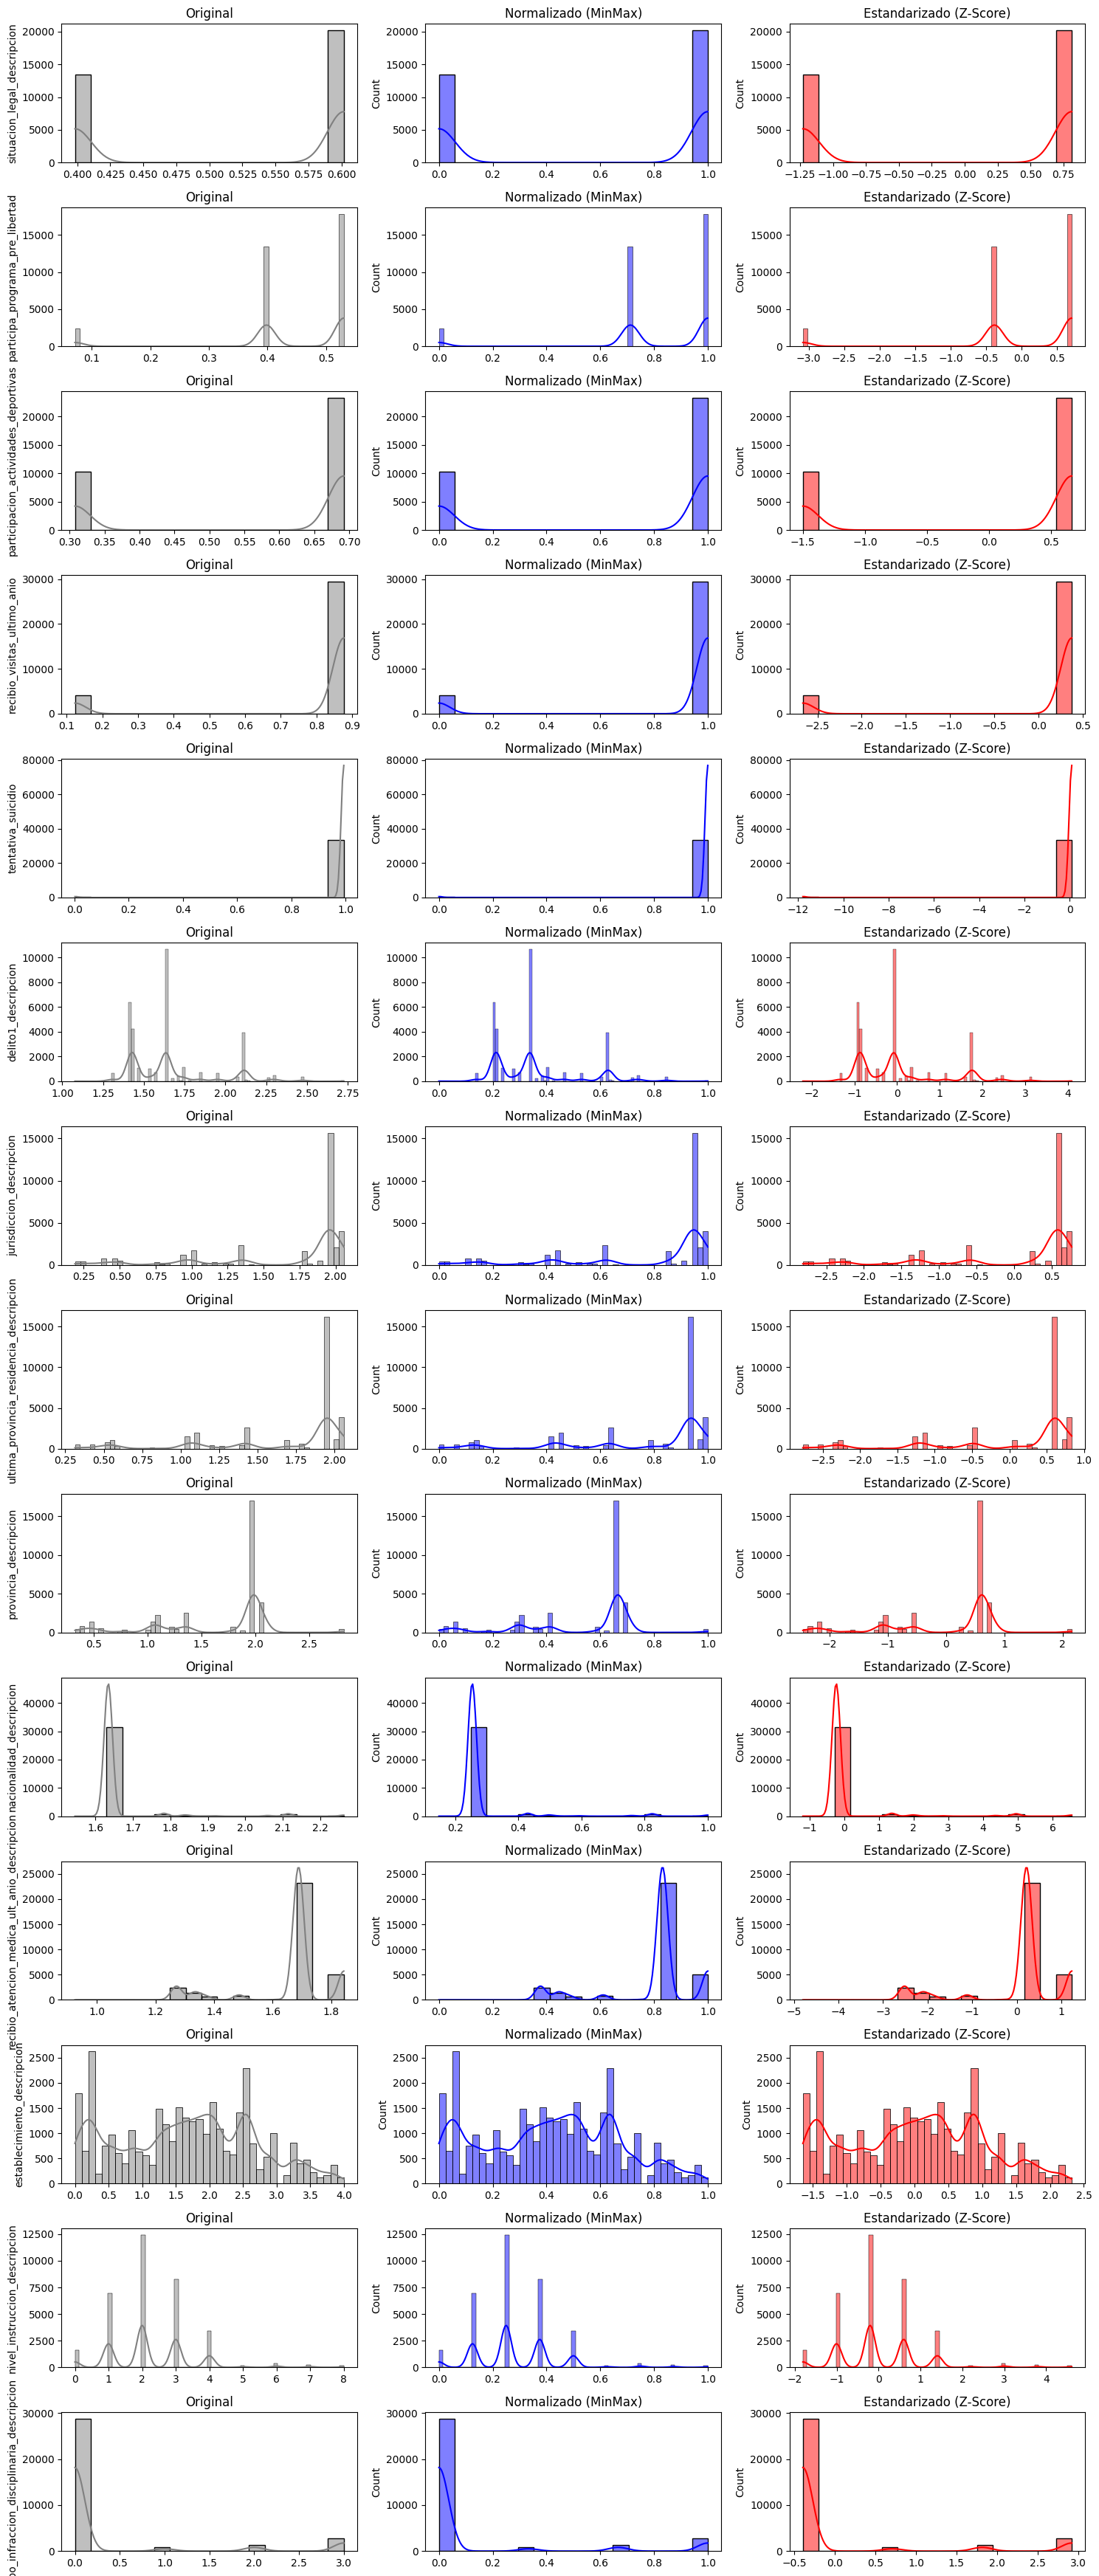

In [147]:
graficar_comparacion_transformaciones(df_original=X_test,
                                      df_normalizado=df_test_escalado,
                                      df_estandarizado=df_test_estandarizado,
                                      columns=cols_categoricas_codificadas,
                                      figsize = (15,35))

Similar a como sucede con las variables numéricas, al aplicar estandarización y normalización a las variables categóricas codificadas, se modifica su escala, más no su distribución.

Se opta por utilizar la estandarización de estas variables, ya que esta puede resultar útil al trabajar con algoritmos tales como `Regresión Lineal` y `SVM`.

#### Paso 7.3.3 - Gráfico de variable target

A continuación se grafica la distribución de la variable `target` en los dataset de `train` *original*, *normalizado* y *estandarizado*.

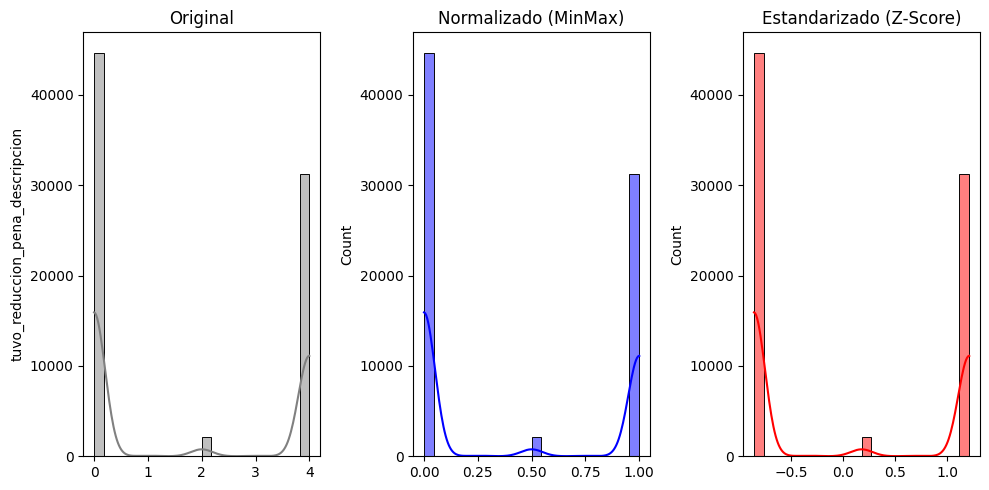

In [148]:
graficar_comparacion_transformaciones(df_original=df_y_train,
                                      df_normalizado=y_train_escalado,
                                      df_estandarizado=y_train_estandarizado,
                                      columns=[target],
                                      figsize=(10,5))

A continuación se grafica la distribución de la variable `target` en los dataset de `test` *original*, *normalizado* y *estandarizado*.

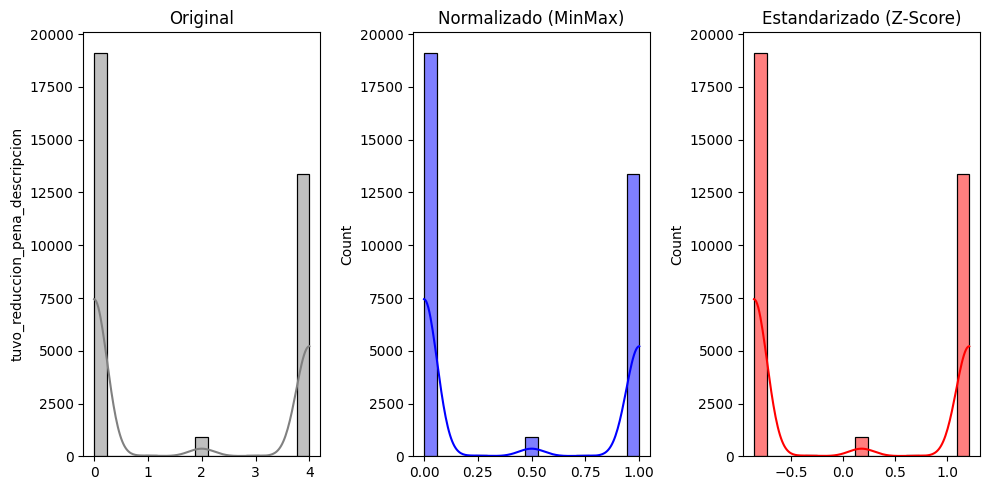

In [149]:
graficar_comparacion_transformaciones(df_original=df_y_test,
                                      df_normalizado=y_test_escalado,
                                      df_estandarizado=y_test_estandarizado,
                                      columns=[target],
                                      figsize=(10,5))

Similar a como sucede con las variables numéricas y con las variables categóricas codificadas, al aplicar estandarización y normalización a la variable target se modifica su escala, más no su distribución.

Se opta por utilizar la estandarización de estas variables, ya que esta puede resultar útil al trabajar con algoritmos tales como `Regresión Lineal` y `SVM`.

### Paso 7.4 - Reemplazo de variables *originales* por estandarizadas

#### Paso 7.4.1 - Reemplazo de variables numéricas *originales* por estandarizadas

In [150]:
# El reset_index es necesario para actualizar correctamente los nuevos valores, sino genera nulos
X_train = X_train.reset_index()
X_test = X_test.reset_index()

In [151]:
for col in col_numericas:
    X_train[col] = df_train_estandarizado[col]
    X_test[col] = df_test_estandarizado[col]

#### Paso 7.4.2 - Reemplazo de variables categóricas codificadas *originales* por estandarizadas

In [152]:
for col in cols_categoricas_codificadas:
    X_train[col] = df_train_estandarizado[col]
    X_test[col] = df_test_estandarizado[col]

#### Paso 7.4.3 - Reemplazo de variables target *originales* por estandarizadas

In [153]:
y_train = y_train_estandarizado[target].values
y_test = y_test_estandarizado[target].values

## Paso 8 - Análisis de desbalance de variable target

### Paso 8.1 - Análisis de presencia de desbalance en target

Comenzamos analizando si la variable target `tuvo_reduccion_pena_descripcion` está desbalanceada o no.

Para ello utilizaremos las siguientes técnicas en el dataset de *train*:

- Análisis de distribución
- Entropía de Shannon

In [154]:
# Función para graficar la distribución de la variable target
def plot(y, colname, figsize=(10,10)):
    fig, axes = plt.subplots(figsize=figsize)
    sns.countplot(x=y, hue=y, palette="Set2", ax=axes)
    
    axes.set_xlabel(colname)
    axes.set_ylabel("Cantidad")
    axes.set_title(f"Distribución de la variable {colname}")

    plt.tight_layout()
    plt.show()

# Calcula la entropía de Shannon
def entropia_de_shannon(y, base=2):
    value_counts = y.value_counts(normalize=True)

    return entropy(pk=value_counts, base=base)

# Calcula el máximo valor posible de entropía
def max_entropia_posible(y):
    unique_values = y.nunique()

    return math.log2(unique_values)

In [155]:
y_train_df = pd.DataFrame(y_train, columns=[target])

A continuación se grafica la distribución de la variable `target` en *train*, luego de haber aplicado codificación y estandarización sobre la misma (ver *Paso 6* y *Paso 7*, respectivamente).

Debido a estas transformaciones, los valores/nombres de categorías graficados son numéricos.

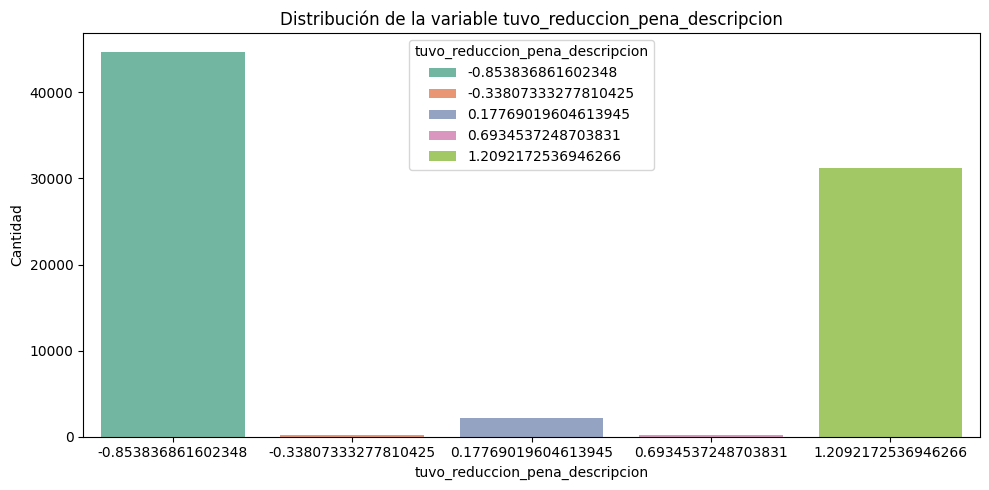

In [156]:
plot(y_train_df[target], target, figsize=(10,5))

En la siguiente celda se obtienen el valor de `Entropía de Shannon` para la variable target, como así también el máximo valor posible para la misma.

Los resultados son $1.17$ para el valor de `Entropía de Shannon`, con un valor máximo de $2.322$.

Esto significa que la entropía para esta variable es baja, lo cual indica *baja incertidumbre*, es decir, tenemos un set de datos ***desbalanceados***.

In [157]:
entropia = entropia_de_shannon(y_train_df[target])
max_entropia = max_entropia_posible(y_train_df[target])

print(entropia)
print(max_entropia)

1.169189183343783
2.321928094887362


In [158]:
# TO-DO: sacar
# Source: https://github.com/oliviaguest/gini
def gini_coefficient3(array):
    """Calculate the Gini coefficient of a numpy array."""
    # based on bottom eq: http://www.statsdirect.com/help/content/image/stat0206_wmf.gif
    # from: http://www.statsdirect.com/help/default.htm#nonparametric_methods/gini.htm
    array = array.flatten() #all values are treated equally, arrays must be 1d
    if np.amin(array) < 0:
        array -= np.amin(array) #values cannot be negative
    array += 0.0000001 #values cannot be 0
    array = np.sort(array) #values must be sorted
    index = np.arange(1,array.shape[0]+1) #index per array element
    n = array.shape[0]#number of array elements
    return ((np.sum((2 * index - n  - 1) * array)) / (n * np.sum(array))) #Gini coefficient    

Como se puede observar, ambos métodos indican que la variable `target` en el dataset de *train* está desbalanceada.

Se procederá a analizar distintas técnicas para el balanceo de esta variable.

### Paso 8.2 - Oversampling y Undersampling

En esta sección se explorarán la técnica de `SMOTE` para *oversampling* y la técnica *aleatoria* para *undersampling*.

In [ ]:
# Obtenemos las columnas categóricas: no consideramos las codificadas; si consideramos las booleanas y tipo_condena.
# col_categoricas_SIN_codificar = list((set(col_categoricas) - set(cols_categoricas_codificadas)))
# col_categoricas_SIN_codificar.extend(["tipo_condena"])

# Generamos un dataframe a partir de y_train, pero con los datos como string, ya que es requerido por SMOTENC
y_train_str = pd.DataFrame(y_train, columns=[target])
y_train_str[target] = y_train_str[target].astype(str)

A continuación utilizamos la clase [SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html#imblearn.over_sampling.SMOTE) para aplicar la técnica de SMOTE sobre el dataset de *train*.

In [160]:
# smote = SMOTENC(categorical_features=col_categoricas_SIN_codificar, random_state=random_state)
# X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train_str[target])

smote = SMOTE(random_state=random_state)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train_str[target])

A continuación se implementa la clase [RandomUnderSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html).

In [161]:
undersample = RandomUnderSampler(random_state=random_state)
X_train_us, y_train_us = undersample.fit_resample(X_train, y_train_str[target])

En el siguiente paso se muestran los gráficos de distribución del dataset de train ***Original***, con técnica ***SmoteNC*** aplicada, y con técnica de ***Undersampling*** aplicada.

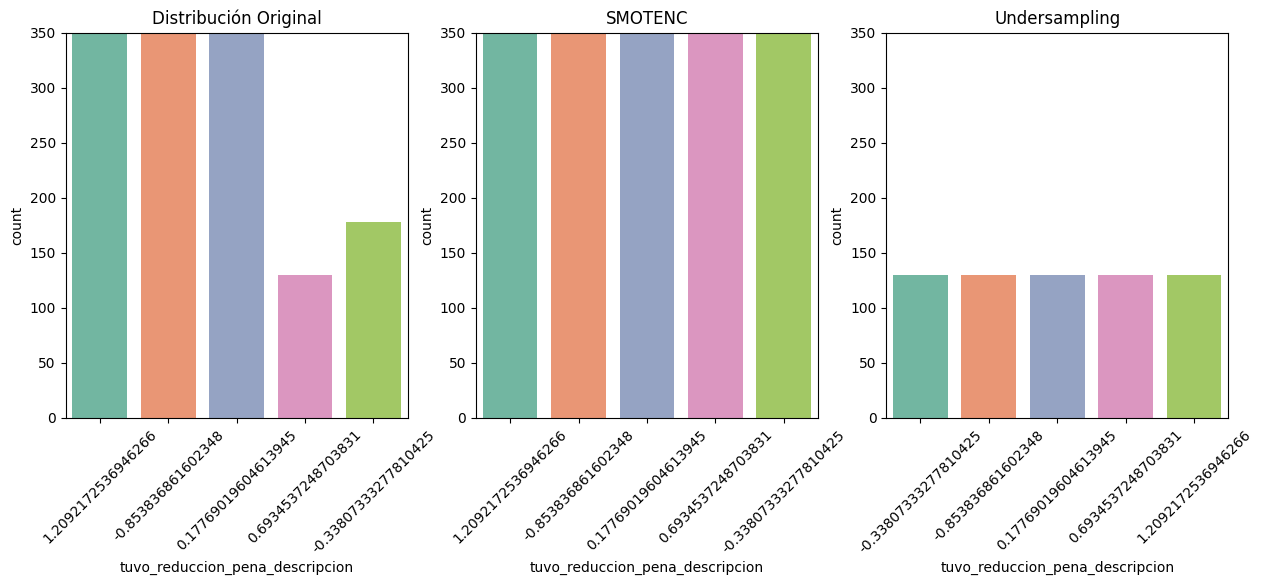

In [162]:
# Grafica las distribuciones original y balanceadas (para compararlas)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.countplot(x=y_train_str[target], hue=y_train_str[target], palette="Set2", ax=axes[0])
sns.countplot(x=y_train_smote, hue=y_train_smote, palette="Set2", ax=axes[1])
sns.countplot(x=y_train_us, hue=y_train_us, palette="Set2", ax=axes[2])

axes[0].set_title('Distribución Original')
axes[1].set_title('SMOTENC')
axes[2].set_title('Undersampling')

axes[0].tick_params("x", labelrotation=45)
axes[1].tick_params("x", labelrotation=45)
axes[2].tick_params("x", labelrotation=45)

for i in (0,1,2):
  axes[i].set_ylim(0,350)

plt.show()

In [164]:
tam_y_train = len(y_train_str)
tam_y_train_sm = len(y_train_smote)
tam_y_train_us = len(y_train_us)

cant_columnas = X_train.shape[1]

print(f"""
    y_train original:       {tam_y_train}
    y_train SmoteNC:        {tam_y_train_sm}
    y_train_undersampling:  {tam_y_train_us}
    Columnas en X_train:    {cant_columnas}
""")


    y_train original:       78376
    y_train SmoteNC:        223460
    y_train_undersampling:  650
    Columnas en X_train:    39



### Paso 8.3 - Conclusiones

El dataset original en *train* tiene $78376$.

- Al aplicar la técnica de `Smote` se aumenta su tamaño a $223460$, en donde cada categoría de la columna `target` tiene la misma cantidad de observaciones.
- Al aplicar la técnica de `Random` undersampling se reduce el tamaño a $650$, logrando que cada categoría de la columna `target` tenga la misma cantidad de observaciones.

La primer técnica (casi) triplica el tamaño original del dataset de *train*, mientras que la segunda lo reduce al $0.83$% de su tamaño original.

Para determinar cual técnica utilizar, nos basaremos en el tamaño de los datasets resultantes.

En el artículo [Recommending Training Set Sizes for Classification](https://www.researchgate.net/publication/349424239_Recommending_Training_Set_Sizes_for_Classification#:~:text=We%20compare%20STSS%20to%20the,classes%20and%20number%20of%20features.), para problemas de *clasificación* se recomiendan datasets que tengan entre $3000$ y $30000$ observaciones, según la cantidad de clases y features.

Por lo mencionado anteriormente, el dataset ideal sería el de `Smote`, ya que la relación *registros-clases* es de $44000$ registros por clase, y la relación *registros-features* es de $5800$ aproximadamente.


In [165]:
X_train = X_train_smote

In [166]:
y_train = y_train_smote.values

## Paso 9 - Selección y extracción de features

### Paso 9.1 - Técnicas de selección - métodos de filtrado

Comenzamos restaurando la variable target al tipo float:

In [167]:
y_train = y_train.astype(float)
y_test = y_test.astype(float)

In [168]:
X_train = X_train.drop(columns="index")
X_test = X_test.drop(columns="index")

In [172]:
col_numericas_procesadas = X_train.columns#cols_a_escalar.copy()

#### Paso 9.1.1 - Métodos de filtrado entre variables numéricas

##### Paso 9.1.1.1 - Correlación de Kendall

Comenzamos calculando la correlación de *Kendall* entre las variable numéricas de *train* y la variable target.

Se elige la correlación de *Kendall* ya que, en comparación con *Spearman*, es mejor porque hay valores repetidos en algunas de las variables a comparar (por ejemplo, `situacion_legal_descripcion`).

In [171]:
# Se muestran los valores repetidos de la variable situacion_legal_descripcion.
X_train["situacion_legal_descripcion"].value_counts()

situacion_legal_descripcion
 0.813561    178768
-1.229164     44692
Name: count, dtype: int64

In [173]:
# Calculamos la correlación de kendall a partir de un nuevo dataset
corr_train = X_train[col_numericas_procesadas].copy()
corr_train[target] = y_train.copy()

kendall_corr = corr_train.corr(method="kendall")

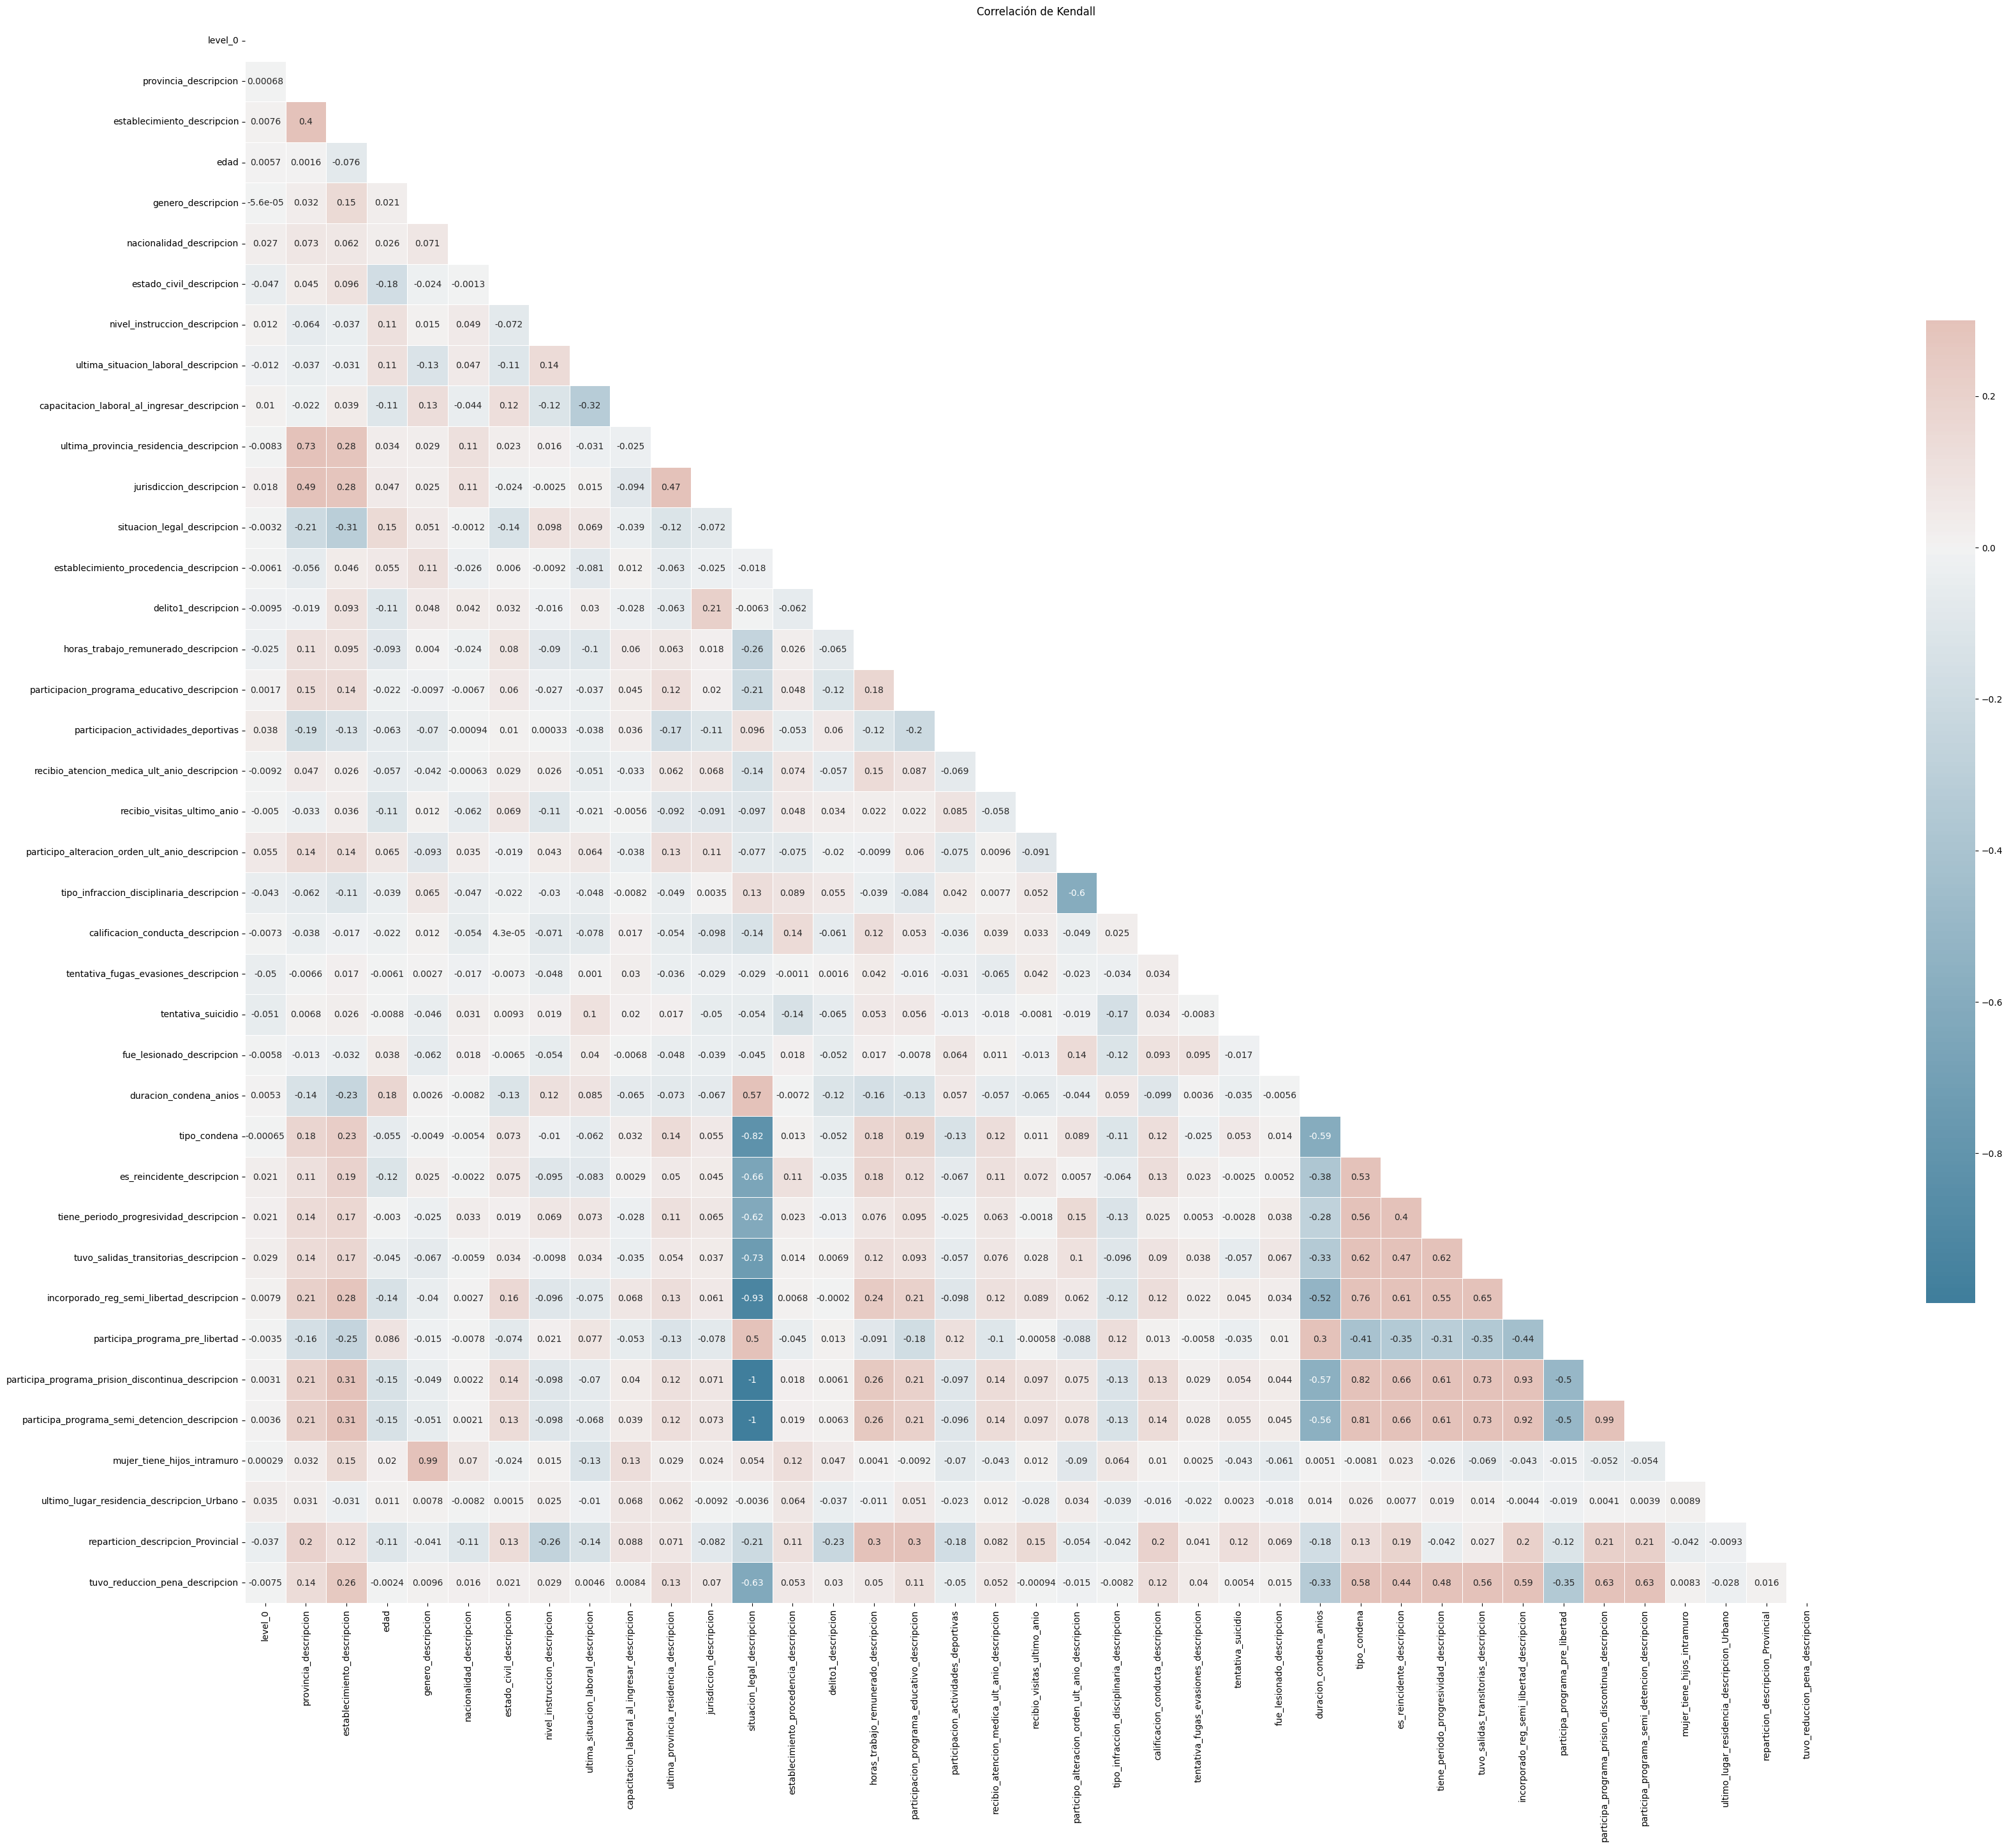

In [177]:
graficar_corrplot(kendall_corr, "Correlación de Kendall", figsize=(40, 40))

En el gráfico anterior se observa que, en términos de valores absolutos, las variables con la variable *target* `tuvo_reduccion_pena_descripcion` son:

- `situacion_legal_descripcion`, con un valor de correlación (negativa) de Kendall de $-0.63$.
- `tuvo_salidas_transitorias_descripcion`, con un valor de correlación de Kendall de $0.56$.
- `tipo_condena`, con un valor de correlación de Kendall de $0.58$.
- `incorporado_reg_semi_libertad_descripcion`, con un valor de correlación de Kendall de $0.59$.
- `participa_programa_prision_discontinua_descripcion`, con un valor de correlación de Kendall de $0.63$.
- `participa_programa_semi_detencion_descripcion`, con un valor de correlación de Kendall de $0.63$.

Con el fin de encontrar otras correlaciones de interés, definimos un umbral de $0.65$ y graficamos aquellas correlaciones cuyo valor absoluto sea mayor a este:

In [179]:
umbral = 0.65
mask_for_heatmap = (kendall_corr.abs() < umbral)

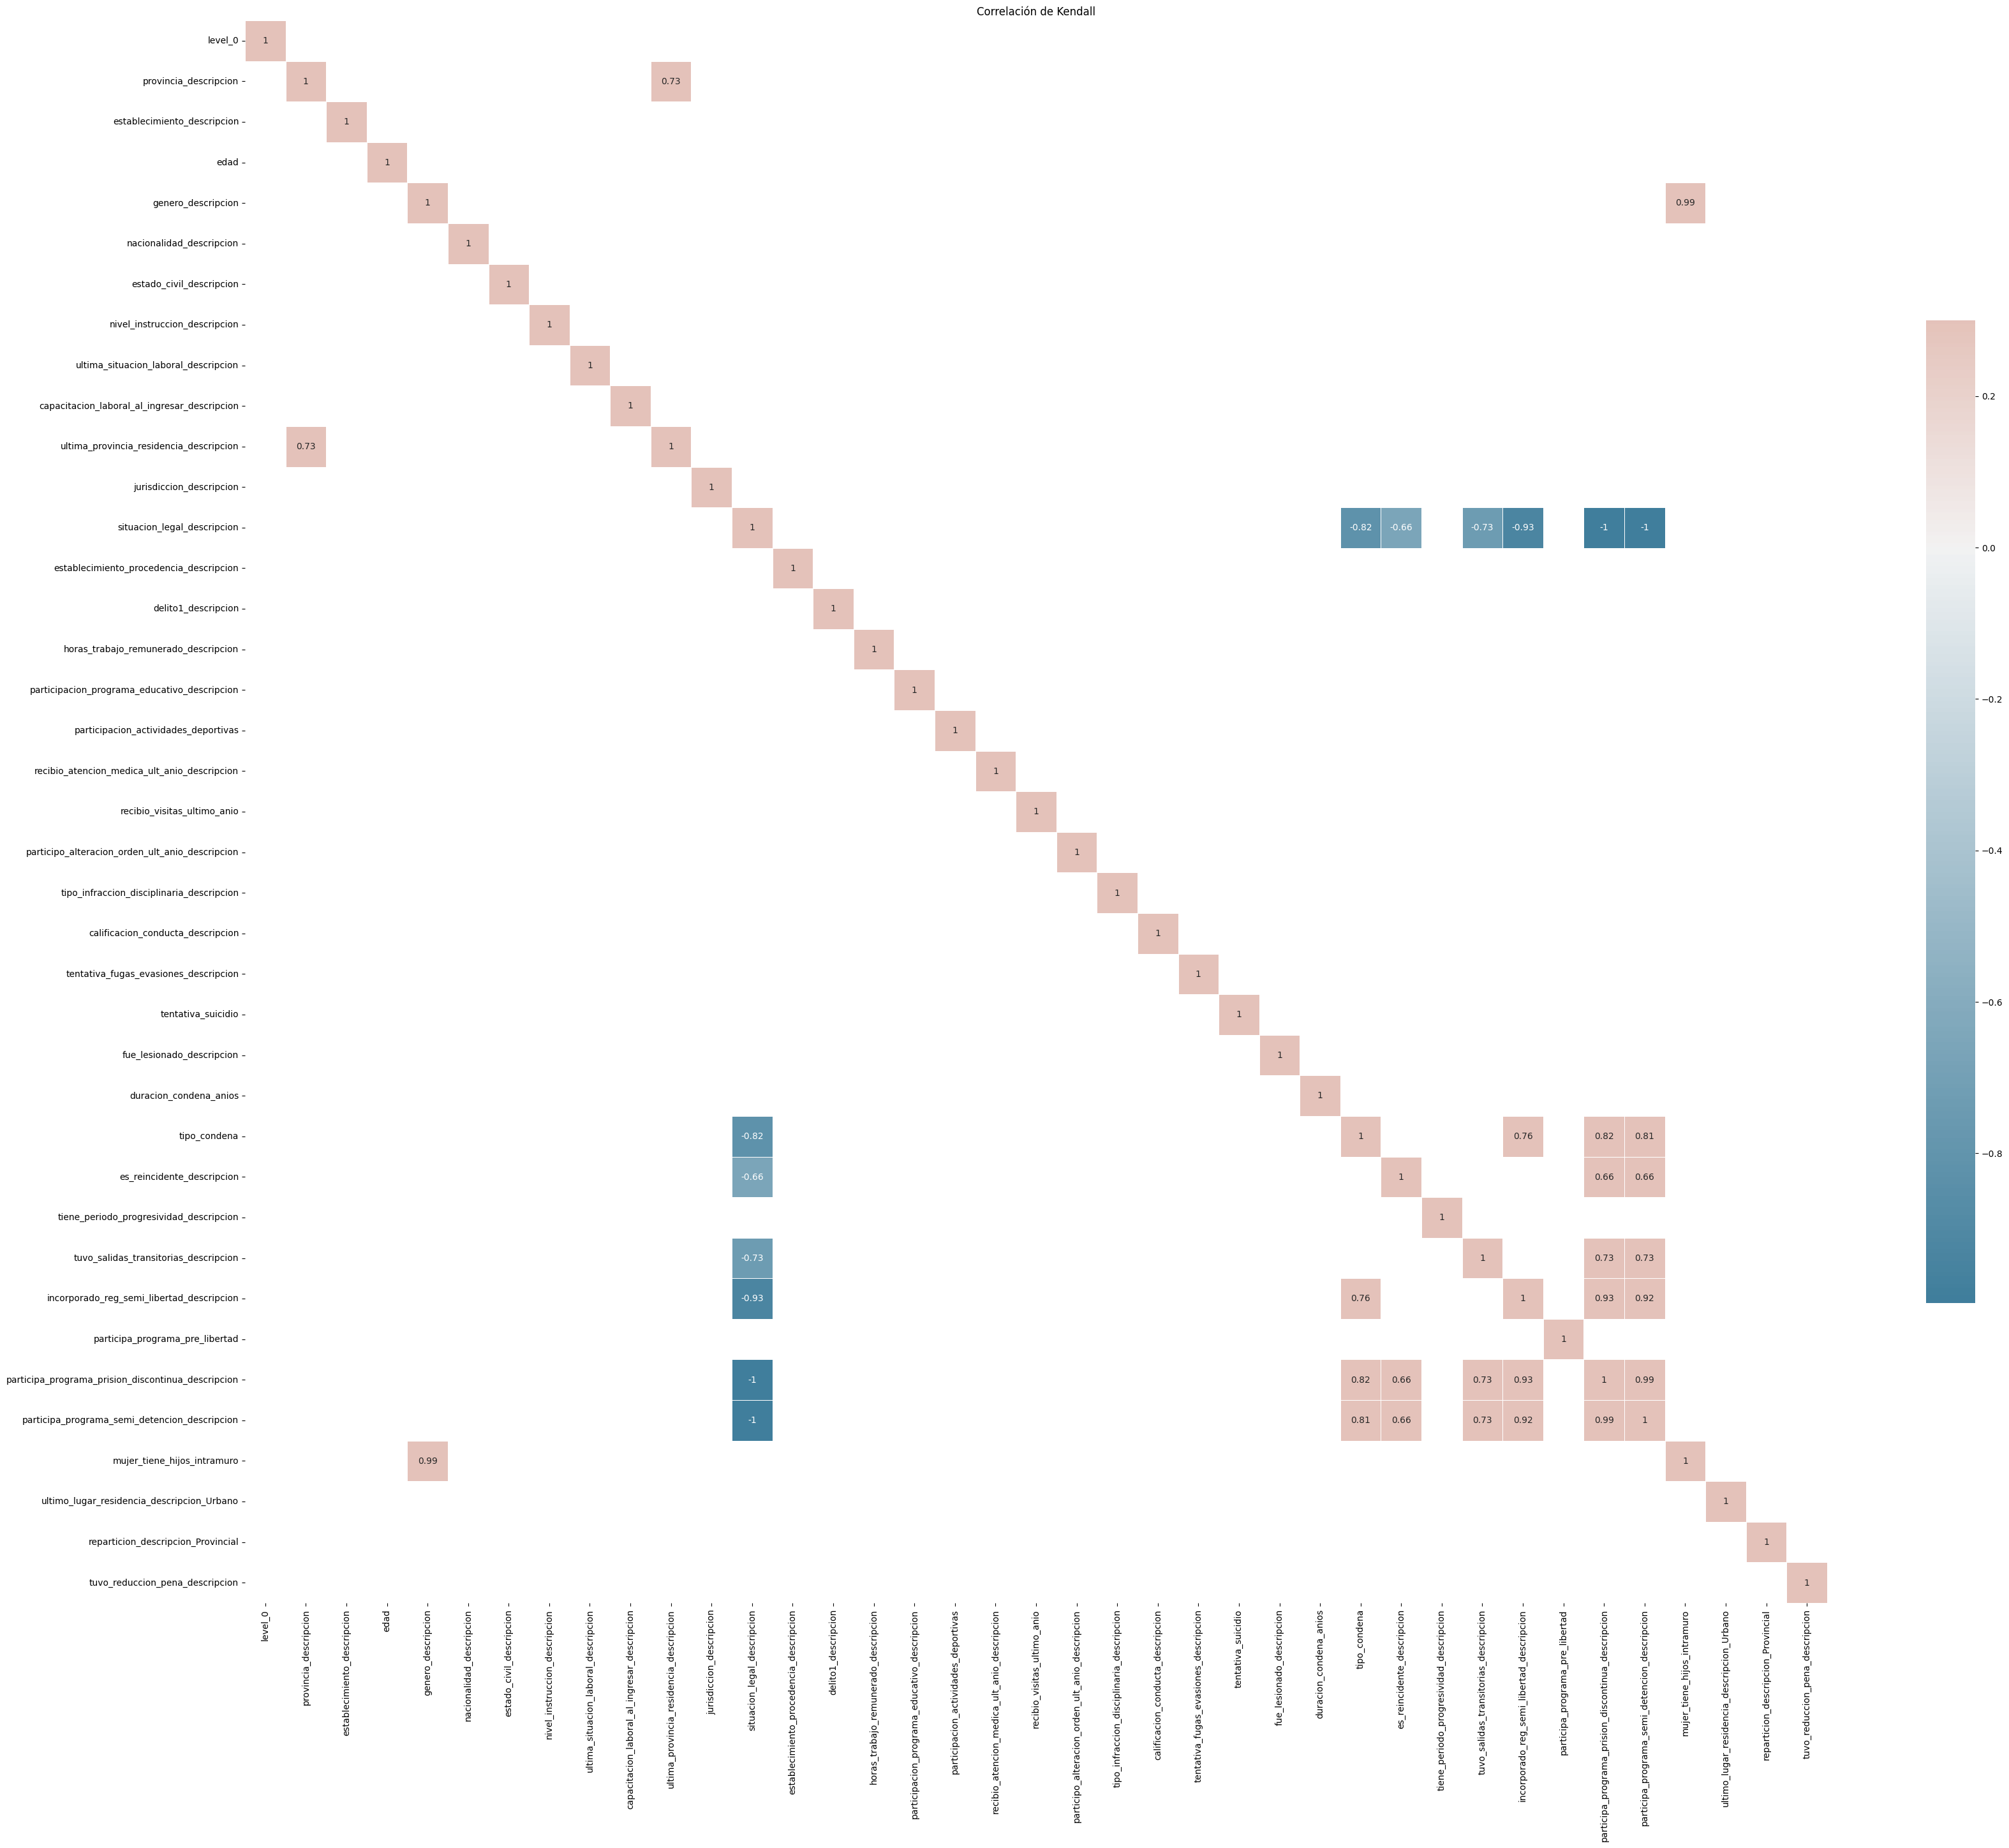

In [180]:
graficar_corrplot(kendall_corr, "Correlación de Kendall", figsize=(40, 40), mask=mask_for_heatmap)

El único par de variables correlacionadas cuyo valor es superior al umbral son:

- `provincia_descripcion` y `ultima_provincia_residencia_descripcion` ($0.73$), lo cual indica que la mayoría de los casos se encuentran en establecimientos ubicados en las mismas provincias donde habitaban previamente entrar al sistema penintenciario.

##### Paso 9.1.1.2 - Información mutua

A continuación se calcula la ***información mutua*** entre las variables numéricas (codificadas) y la variable target.

Para ellos, utilizamos el score function de [mutual_info_regression](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_regression.html#sklearn.feature_selection.mutual_info_regression), ya que nuestro target es un valor numérico.

In [181]:
features_to_select = 10

X_train_mi = X_train[col_numericas_procesadas]
X_test_mi = X_test[col_numericas_procesadas]

In [182]:
selector_mi = SelectKBest(score_func=mutual_info_regression, k=features_to_select)
X_train_best = selector_mi.fit_transform(X_train_mi, y_train)

selected_indices = selector_mi.get_support()
selected_features = X_train_mi.columns[selected_indices]
scores = selector_mi.scores_[selected_indices]

print("\nCaracterísticas seleccionadas (Inf. mutua):")
for feature, score in zip(selected_features, scores):
    print(f"{feature}: {score:.4f}")

X_test_best = selector_mi.transform(X_test_mi)


Características seleccionadas (Inf. mutua):
establecimiento_descripcion: 0.7127
situacion_legal_descripcion: 0.5017
duracion_condena_anios: 0.7824
tipo_condena: 0.5477
es_reincidente_descripcion: 0.6133
tiene_periodo_progresividad_descripcion: 0.7110
tuvo_salidas_transitorias_descripcion: 0.5601
incorporado_reg_semi_libertad_descripcion: 0.5176
participa_programa_pre_libertad: 0.5535
participa_programa_semi_detencion_descripcion: 0.5017


Estas son las 10 variables que más información proporcionan sobre el *target* según el método de *información mutua*:

| Variable | Medida |
| --- | --- |
| duracion_condena_anios | 0.7957 |
| establecimiento_descripcion | 0.7325 |
| participa_programa_pre_libertad | 0.5524 |
| situacion_legal_descripcion | 0.4991 |
| edad | 0.4963 |
| jurisdiccion_descripcion | 0.4331 |
| ultima_provincia_residencia_descripcion | 0.4128 |
| provincia_descripcion | 0.3861 |
| delito1_descripcion | 0.3236 |
| nivel_instruccion_descripcion | 0.3142 |

Si definimos un punto de corte de $0.5$, nos quedaríamos con las siguientes variables:

- `duracion_condena_anios` ($0.7957$)
- `establecimiento_descripcion` ($0.7325$)
- `participa_programa_pre_libertad` ($0.5524$)

Como detalle, la variable a seleccionar según la correlación de Kendall fue `situacion_legal_descripcion` (correlación negativa de $-0.63$), la cual mediante este método obtiene un valor de $0.4991$, apenas por debajo del umbral de $0.5$ definido.

#### Paso 9.1.2 - Métodos de filtrado entre variables categóricas